# EDA – Tổng quan dữ liệu và trả lời câu hỏi

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re


PRE_MERGED = "../data/unified/preprocessed_merged.csv"

df = pd.read_csv(PRE_MERGED, encoding="utf-8-sig", encoding_errors="ignore", on_bad_lines="skip")


## 1) Tổng quan dữ liệu

In [3]:
df.columns

Index(['tieu_de', 'gia', 'dia_chi', 'dien_tich_dat', 'phong_ngu', 'phong_tam',
       'so_tang', 'phap_ly', 'ngay_dang', 'quan', 'thanh_pho', 'gia_tren_m2',
       'diem_sinh_loi'],
      dtype='object')

### 1.1 Ý nghĩa của từng cột dữ liệu
- tieu_de: Tiêu đề bài đăng bán nhà
- gia: Giá bán (theo tỷ đồng)
- dia_chi: Địa chỉ nhà
- dien_tich_dat: Diện tích đất (theo mét vuông)
- phong_ngu: Số phòng ngủ của nhà
- phong_tam: Số phòng tắm của nhà
- so_tang: Số tầng của nhà
- phap_ly: Tình trạng pháp lý (Sổ hồng, Số đỏ, Giấy tờ không xác định)
- ngay_dang: Ngày đăng tin bán nhà
- gia_tren_m2: Giá đất trên mét vuông 
- diem_sinh_loi: Điểm số mà dòng tiền mang lại khi cho thuê

### 1.2 Kiểu dữ liệu của từng cột hiện tại

In [4]:
df.dtypes

tieu_de           object
gia              float64
dia_chi           object
dien_tich_dat    float64
phong_ngu          int64
phong_tam          int64
so_tang            int64
phap_ly           object
ngay_dang         object
quan              object
thanh_pho         object
gia_tren_m2      float64
diem_sinh_loi    float64
dtype: object

### 1.3 Kiểm tra và xử lí số dòng thiếu và trùng lặp

In [5]:
print("Số dòng:", len(df))
print("Số ô missing value:", df.isna().sum().sum())
print("Số dòng bị trùng lặp (tính cả dòng giống hệt nhau):", df.duplicated().sum())



Số dòng: 6973
Số ô missing value: 0
Số dòng bị trùng lặp (tính cả dòng giống hệt nhau): 5


In [6]:
df = df.drop_duplicates(inplace=False)
print("Số dòng sau khi xoá trùng lặp:", len(df))


Số dòng sau khi xoá trùng lặp: 6968


### 1.4 Phân tích dữ liệu với các dữ liệu kiểu object

In [7]:
print("Số giá trị duy nhất của tiêu đề là: ",df['tieu_de'].nunique())
print("Số giá trị duy nhất của địa chỉ là: ", df['dia_chi'].nunique())
print("Số giá trị duy nhất của quận là: ", df['quan'].nunique())
print("Số giá trị duy nhất của thành phố là: ", df['thanh_pho'].nunique())
print("Số giá trị duy nhất của pháp lý là: ", df['phap_ly'].nunique(),df['phap_ly'].unique())
print("Số giá trị duy nhất của ngày đăng là: ", df['ngay_dang'].nunique())

df['ngay_dang'] = pd.to_datetime(df['ngay_dang'], errors='coerce')
print("Ngày đăng lớn nhất",df['ngay_dang'].min().date())
print("Ngày đăng lớn nhất:", df['ngay_dang'].max().date())

df.columns




Số giá trị duy nhất của tiêu đề là:  6430
Số giá trị duy nhất của địa chỉ là:  3432
Số giá trị duy nhất của quận là:  31
Số giá trị duy nhất của thành phố là:  2
Số giá trị duy nhất của pháp lý là:  3 ['Sổ hồng' 'Sổ đỏ' 'Giấy tờ không xác định']
Số giá trị duy nhất của ngày đăng là:  250
Ngày đăng lớn nhất 2024-10-31
Ngày đăng lớn nhất: 2025-11-28


Index(['tieu_de', 'gia', 'dia_chi', 'dien_tich_dat', 'phong_ngu', 'phong_tam',
       'so_tang', 'phap_ly', 'ngay_dang', 'quan', 'thanh_pho', 'gia_tren_m2',
       'diem_sinh_loi'],
      dtype='object')

### 1.5 Phân tích và xử lí dữ liệu với các dữ liệu dạng numeric


In [8]:
df.describe()

,gia,dien_tich_dat,phong_ngu,phong_tam,so_tang,ngay_dang,gia_tren_m2,diem_sinh_loi
count,6968.000000,6968.000000,6968.000000,6968.000000,6968.000000,6968,6968.000000,6968.000000
mean,25.775581,75.197796,4.800230,4.737084,6.015212,2025-10-12 01:19:33.823191552,0.450448,16.743955
min,0.014000,1.500000,1.000000,1.000000,1.000000,2024-10-31 00:00:00,0.000000,3.500000
25%,6.400000,38.350000,3.000000,3.000000,3.000000,2025-10-16 00:00:00,0.130000,11.000000
50%,9.300000,54.200000,4.000000,4.000000,4.000000,2025-11-18 00:00:00,0.200000,13.000000
75%,17.585000,80.000000,5.000000,5.000000,5.000000,2025-11-25 00:00:00,0.280000,17.800000
max,9400.000000,6117.000000,100.000000,101.000000,9810.000000,2025-11-28 00:00:00,228.330000,9828.000000
std,246.682781,125.013111,4.869827,4.844212,117.529060,NaN,6.183962,117.925680


In [9]:
# Xử lí outlier dựa theo cảm quan và quan sát thủ công dữ liệu
df = df[(df['gia'] <=500) & (df['so_tang'] <= 16) & (df['phong_ngu'] <= 30) & (df['phong_tam'] <= 30) & (df['dien_tich_dat'] <= 3000)]

df.describe()

,gia,dien_tich_dat,phong_ngu,phong_tam,so_tang,ngay_dang,gia_tren_m2,diem_sinh_loi
count,6871.000000,6871.000000,6871.000000,6871.000000,6871.000000,6871,6871.000000,6871.000000
mean,16.592332,71.940626,4.510261,4.447970,4.427740,2025-10-12 02:05:57.327899904,0.224729,14.780972
min,0.014000,5.000000,1.000000,1.000000,1.000000,2024-10-31 00:00:00,0.000000,3.500000
25%,6.350000,38.000000,3.000000,3.000000,3.000000,2025-10-16 00:00:00,0.130000,11.000000
50%,9.200000,54.000000,4.000000,4.000000,4.000000,2025-11-17 00:00:00,0.200000,13.000000
75%,17.000000,80.000000,5.000000,5.000000,5.000000,2025-11-25 00:00:00,0.270000,17.000000
max,450.000000,2515.000000,30.000000,30.000000,16.000000,2025-11-28 00:00:00,9.000000,69.000000
std,25.516467,81.241356,2.978991,2.992401,2.037061,NaN,0.178866,7.009241


### 1.6 Tương quan giữa các cột numberic

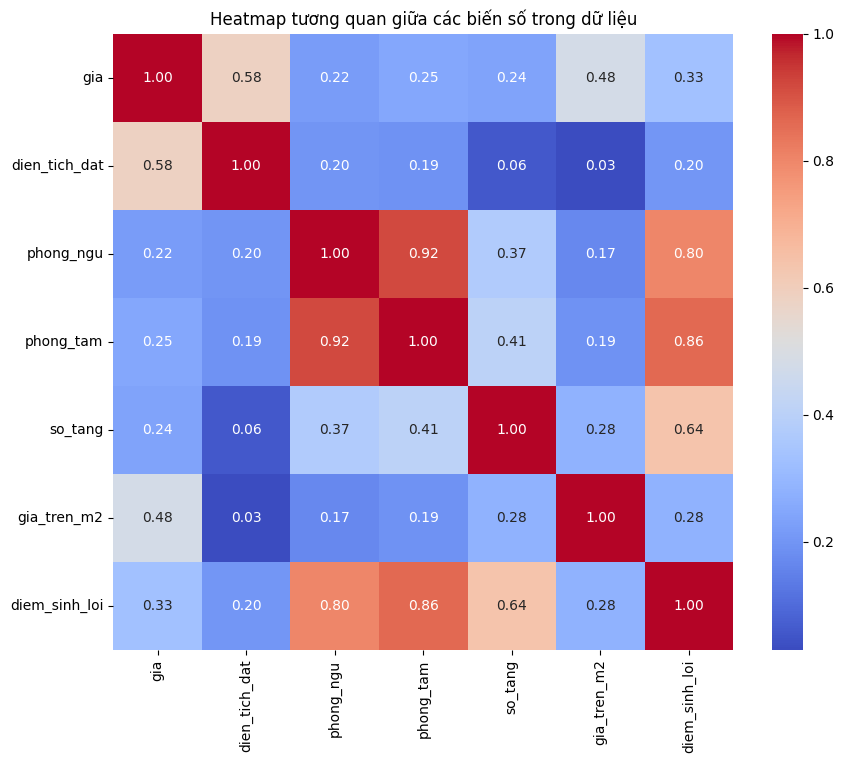

In [10]:


# Tính ma trận tương quan
corr_matrix = df.corr(numeric_only=True)

# Vẽ heatmap cho ma trận tương quan
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap tương quan giữa các biến số trong dữ liệu")
plt.show()


Nhận xét: Giá có sự tương quan mạnh nhất với diện tích đất và diem_sinh_loi có tương quan mạnh nhất với phong_ngu,phong_tam, so_tang bởi vì diem_sinh_loi chủ yếu được tính dựa trên các thuộc tính này để xem có phù hợp để cho thuê hay không

## 2) EDA để trả lời câu hỏi

### 2.1 Câu hỏi 1
-   Câu hỏi: Tỷ lệ các loại pháp lý (sổ đỏ/sổ hồng, giấy tờ không xác định) theo quận/thành phố?

In [11]:
# Tỷ lệ theo THÀNH PHỐ
ty_le_theo_thanh_pho = (
    pd.crosstab(df['thanh_pho'], df['phap_ly'], normalize='index') * 100
).round(2)

print("Tỷ lệ pháp lý theo THÀNH PHỐ (%):")
print(ty_le_theo_thanh_pho)

# Tỷ lệ theo QUẬN trong từng THÀNH PHỐ
ty_le_theo_quan = (
    pd.crosstab([df['thanh_pho'], df['quan']], df['phap_ly'], normalize='index') * 100
).round(2)

print("\nTỷ lệ pháp lý theo QUẬN trong từng THÀNH PHỐ (%):")
print(ty_le_theo_quan)



Tỷ lệ pháp lý theo THÀNH PHỐ (%):
phap_ly      Giấy tờ không xác định  Sổ hồng  Sổ đỏ
thanh_pho                                          
Hà Nội                        34.83    46.52  18.66
Hồ Chí Minh                    8.44    91.28   0.28

Tỷ lệ pháp lý theo QUẬN trong từng THÀNH PHỐ (%):
phap_ly                        Giấy tờ không xác định  Sổ hồng  Sổ đỏ
thanh_pho   quan                                                     
Hà Nội      Quận Ba Đình                        56.02     3.38  40.60
            Quận Bắc Từ Liêm                     7.84    92.16   0.00
            Quận Cầu Giấy                       62.80     8.29  28.91
            Quận Hai Bà Trưng                   44.77    12.09  43.14
            Quận Hoàn Kiếm                      19.30    10.53  70.18
            Quận Hoàng Mai                      10.19    89.81   0.00
            Quận Hà Đông                         4.58    95.42   0.00
            Quận Long Biên                       7.04    92.96   0.00
       

### Visualize kết quả


### Tỷ lệ pháp lý theo thành phố

<Figure size 800x500 with 0 Axes>

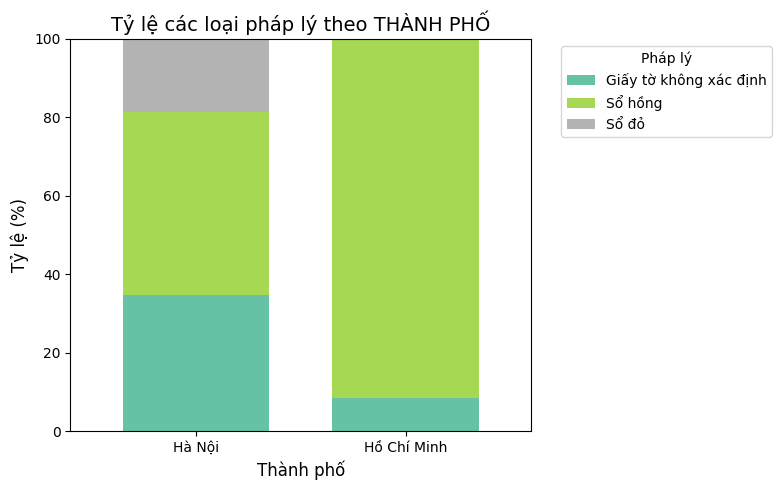

In [12]:

plt.figure(figsize=(8, 5));

ax = ty_le_theo_thanh_pho.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    colormap='Set2',   # hoặc 'tab20', 'Pastel1', ...
    width=0.7
);

ax.set_title('Tỷ lệ các loại pháp lý theo THÀNH PHỐ', fontsize=14);
ax.set_xlabel('Thành phố', fontsize=12)
ax.set_ylabel('Tỷ lệ (%)', fontsize=12)
ax.set_ylim(0, 100);

plt.xticks(rotation=0)           # tên TP nằm ngang
plt.legend(title='Pháp lý', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show();

Nhận xét: Khoảng 90% tin đăng ở TP. Hồ Chí Minh có Sổ Hồng và chỉ 10% là Giấy tờ không xác định, gần như là không có Sổ đỏ cho thấy Các tin ở HCM tính chuẩn hóa pháp lý khá cao, gần như “mặc định” là Sổ hồng,tỷ lệ tin pháp lý mơ hồ thấp. Còn ở Hà Nội khoảng 40% là giấy tờ không xác định(tỷ lệ rất lớn),và vẫn còn khá lớn tỷ lệ đáng kể bất động sản mang Sổ đỏ

### Tỷ lệ pháp lý theo quận Hà Nội

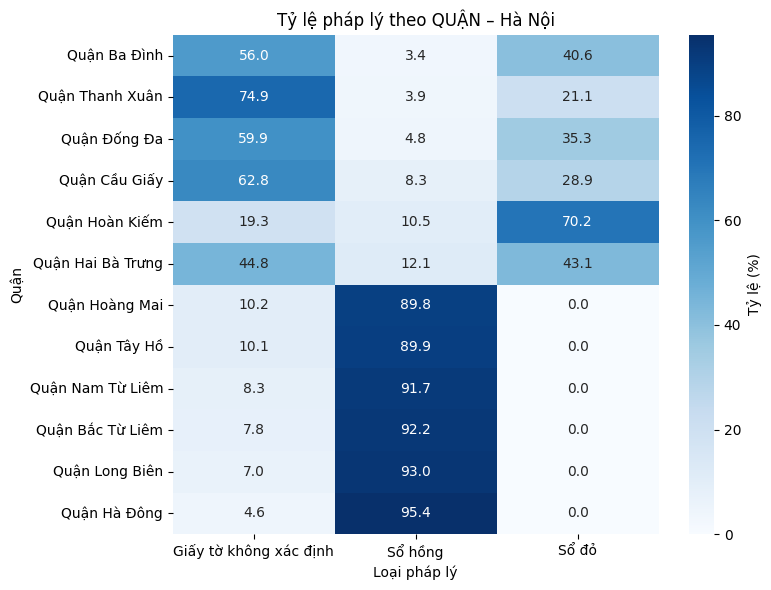

In [13]:


# --- Hà Nội ---
ty_hn = ty_le_theo_quan.xs('Hà Nội')   # lấy phần index 'Hà Nội'
ty_hn = ty_hn.sort_values('Sổ hồng')   # tuỳ chọn: sắp xếp theo % sổ hồng

plt.figure(figsize=(8, 6))
sns.heatmap(
    ty_hn,
    annot=True, fmt='.1f', cmap='Blues',
    cbar_kws={'label': 'Tỷ lệ (%)'}
)
plt.title('Tỷ lệ pháp lý theo QUẬN – Hà Nội')
plt.xlabel('Loại pháp lý')
plt.ylabel('Quận')
plt.tight_layout()
plt.show()


Nhận xét: Các quận trung tâm như Hoàn Kiếm, Ba Đình, Đống Đa, Hai Bà Trưng, Thanh Xuân, Cầu Giấy có nhiều Sổ đỏ nhưng cũng rất nhiều tin không ghi rõ pháp lý. Các quận còn lại có tỷ lệ Sổ hồng áp đảo, thể hiện sự chuẩn hóa hơn.

### Tỷ lệ pháp lý theo quận Hồ Chí Minh

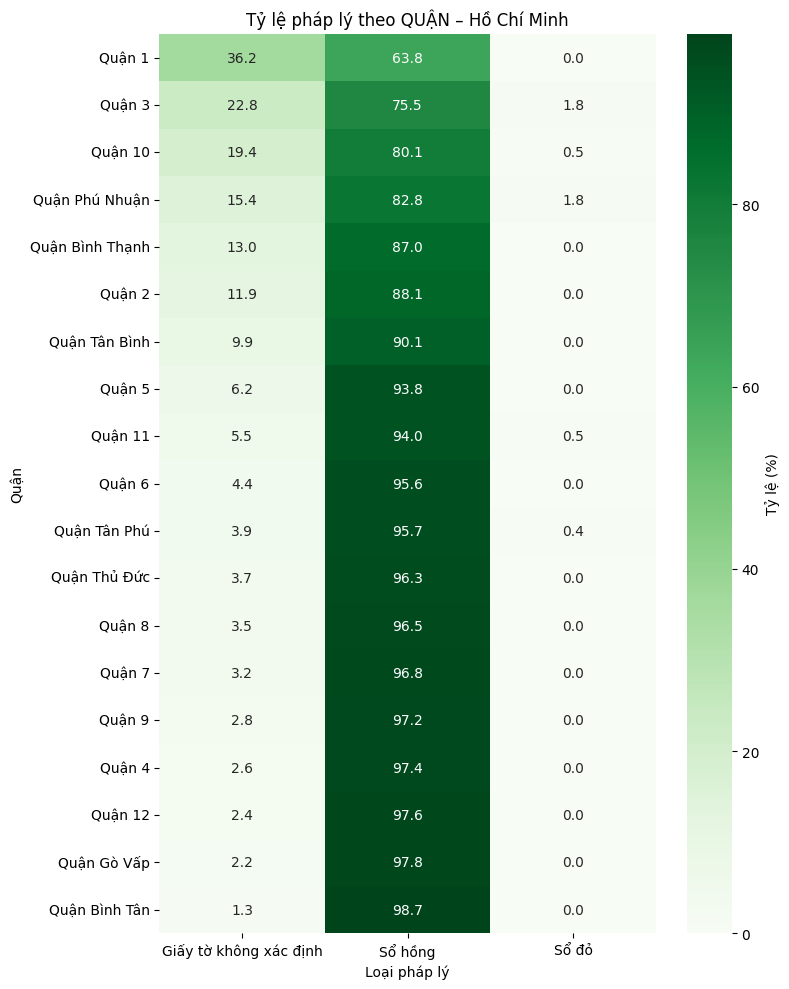

In [14]:
# --- Hồ Chí Minh ---
ty_hcm = ty_le_theo_quan.xs('Hồ Chí Minh')
ty_hcm = ty_hcm.sort_values('Sổ hồng')

plt.figure(figsize=(8, 10))
sns.heatmap(
    ty_hcm,
    annot=True, fmt='.1f', cmap='Greens',
    cbar_kws={'label': 'Tỷ lệ (%)'}
)
plt.title('Tỷ lệ pháp lý theo QUẬN – Hồ Chí Minh')
plt.xlabel('Loại pháp lý')
plt.ylabel('Quận')
plt.tight_layout()
plt.show()

Nhận xét: Ở TPHCM đa số toàn số hồng, rất ít sổ đỏ khác biệt chủ yếu nằm ở tỷ lệ tin “Giấy tờ không xác định”, cao nhất ở các quận như (Q1, Bình Thạnh, Phú Nhuận, Q3, Q10, Tân Bình).


### Kết luận
So sánh theo thành phố
- Nếu chỉ nhìn tổng thể, mua nhà ở HCM có xác suất cao gặp tài sản mang Sổ hồng, ít “giấy tờ lạ”.
- Ở Hà Nội, người mua/nhà đầu tư cần đọc kỹ phần mô tả pháp lý, vì tỷ lệ tin không ghi rõ hoặc không chuẩn hoá khá lớn; đồng thời vẫn tồn tại hai tỉ lệ là Sổ đỏ – Sổ hồng.

So sánh theo quận ở Hà Nội
- Đối với các quận Hoàn Kiếm, Ba Đình, Đống Đa, Hai Bà Trưng, Thanh Xuân, Cầu Giấy có nhiều Sổ đỏ nhưng cũng rất nhiều tin không ghi rõ pháp lý dẫn đến đây có thể là các quận có rủi ro cao,cần thẩm định kỹ từng tài sản.
- Đối với các quận còn lại thì ít rủi ro về “loại sổ”, phù hợp với người mua ưu tiên tính rõ ràng.

So sánh theo quận ở TP.Hồ Chí Minh
- HCM nhìn chung an toàn về loại giấy tờ (gần như toàn Sổ hồng).
- Nếu cần cẩn trọng hơn, đó là những quận trung tâm như Q1, Q3, Bình Thạnh, Phú Nhuận, Q10, Tân Bình, nơi tỷ lệ tin “không rõ pháp lý” cao hơn đáng kể. Trong đó đặc biệt là quận 1 với 36.2% "Giấy tờ không xác định"

Ứng dụng thực tế cho người mua/nhà đầu tư là có thể dùng bản đồ tỷ lệ pháp lý để chọn khu vực phù hợp rủi ro:
- Ưa an toàn, rõ ràng thì ưu tiên các quận “toàn Sổ hồng” thường là các khu vực ven thành phố
- Chấp nhận pháp lý đa dạng để săn tài sản đặc biệt (nhà phố cũ, vị trí hiếm…) nhưng cũng cần hiểu rõ và làm rõ về các loại giấy tờ nếu mua nhà thường là các quận trung tâm Hà Nội/HCM.



### 2.2 Câu hỏi 2

#### Câu hỏi: Quận nào có mức độ phân tán giá cao?
    Ý nghĩa:
- Đối với nhà đầu tư cá nhân <br>
Quận có mức độ phân mảnh giá cao là nơi tồn tại đồng thời nhiều mức giá khác nhau trong cùng khu vực. Điều này tạo điều kiện cho nhà đầu tư cá nhân tìm kiếm các bất động sản được định giá thấp hơn mức trung vị của quận, từ đó tận dụng lợi thế chọn lọc vị trí thay vì phụ thuộc vào xu hướng tăng giá chung.

- Đối với nhà môi giới và công tác định giá <br>
Thị trường phân mảnh đòi hỏi phương pháp định giá dựa trên so sánh tương đồng và phân tích phân phối giá, thay vì chỉ dựa vào giá trung bình. Việc xác định các quận có phân mảnh cao giúp giảm rủi ro định giá sai do khác biệt lớn giữa các phân khúc như hẻm nhỏ và trục đường lớn.

- Đối với người mua để ở <br>
Trong các quận có phân mảnh giá cao, người mua để ở vẫn có khả năng tiếp cận các bất động sản phù hợp ngân sách, do mặt bằng giá chưa bị đẩy lên đồng loạt trên toàn quận.

- Giới hạn của phân tích <br>
Do dữ liệu chỉ được thu thập trong thời gian ngắn, kết quả phân tích chỉ phản ánh cấu trúc giá tại thời điểm hiện tại và không nhằm kết luận về xu hướng tái phát triển hay biến động giá trong dài hạn

Chuẩn bị dữ liệu

In [15]:
# Sao chép dữ liệu
df_analysis = df.copy()


#### Biến và thước đo sử dụng

Phân tích tập trung vào biến `gia_tren_m2` nhằm loại bỏ ảnh hưởng của diện tích bất động sản.

Mức độ phân mảnh giá trong mỗi quận được đo bằng các chỉ số:
- Giá trung bình (mean)
- Giá trung vị (median)
- Độ lệch chuẩn (standard deviation)
- Hệ số biến thiên (Coefficient of Variation – CV)

Trong đó, hệ số biến thiên (CV) được sử dụng làm chỉ số chính để so sánh mức độ phân mảnh giữa các quận do đã chuẩn hóa theo mặt bằng giá.<br>
CV giúp loại bỏ yếu tố "mặt bằng giá". Ví dụ: Quận 1 có độ lệch chuẩn 50 triệu nhưng giá trung bình 500 triệu ($CV = 0.1$) thì thực chất lại ít phân mảnh hơn một quận ngoại thành có độ lệch chuẩn 20 triệu nhưng giá trung bình chỉ 100 triệu ($CV = 0.2$).


In [16]:
summary_by_quan = (
    df_analysis
    .groupby('quan')['gia_tren_m2']
    .agg(
        so_luong='count',
        mean='mean',
        median='median',
        std='std'
    )
    .reset_index()
)

summary_by_quan['cv'] = summary_by_quan['std'] / summary_by_quan['mean']


Trực quan hóa chỉ số CV từng quận

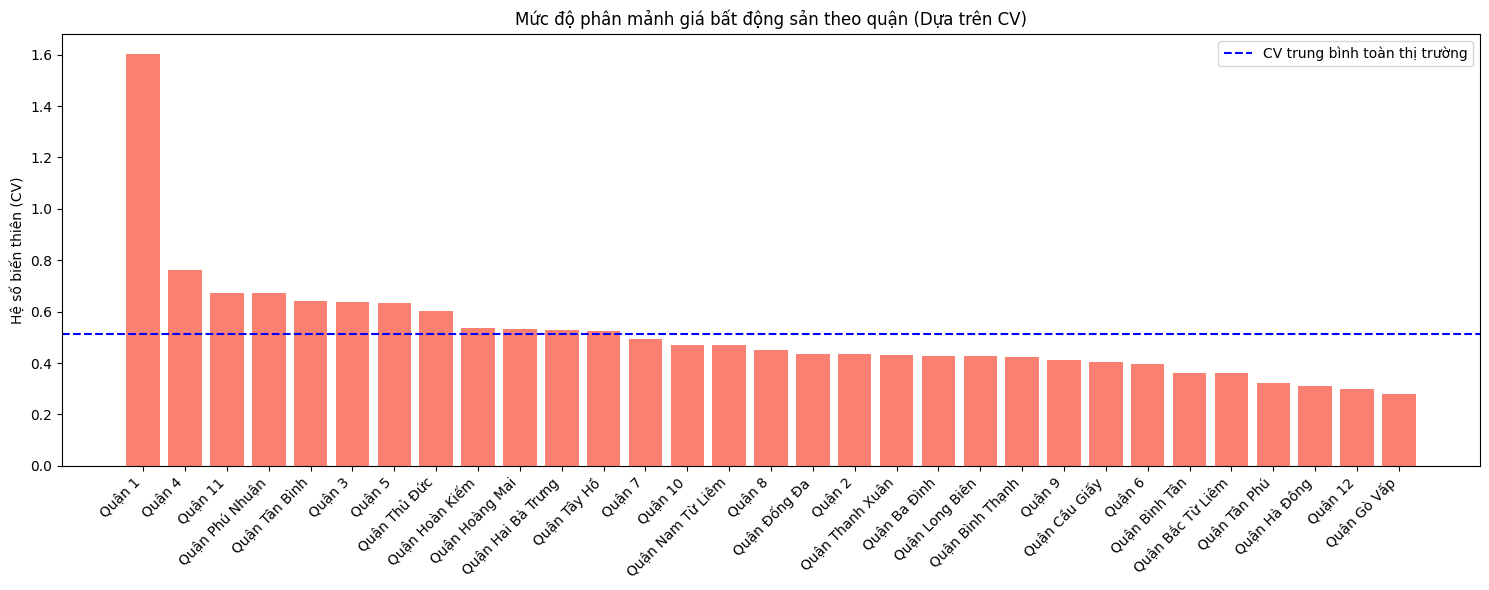

In [17]:
# Sắp xếp theo CV để tìm quận phân mảnh nhất
summary_by_quan_cv = summary_by_quan.sort_values(by='cv', ascending=False)

plt.figure(figsize=(15, 6))
plt.bar(summary_by_quan_cv['quan'], summary_by_quan_cv['cv'], color='salmon')

plt.xticks(rotation=45, ha='right')
plt.ylabel('Hệ số biến thiên (CV)')
plt.title('Mức độ phân mảnh giá bất động sản theo quận (Dựa trên CV)')
plt.axhline(y=summary_by_quan['cv'].mean(), color='blue', linestyle='--', label='CV trung bình toàn thị trường')
plt.legend()
plt.tight_layout()
plt.show()

#### Nhận xét
1. Quận phân mảnh nhất: Quận 1 chiếm vị trí độc tôn
- Chỉ số CV: Quận 1 có hệ số biến thiên (CV) vọt lên mức ~1.6, cao gấp hơn 3 lần mức trung bình toàn thị trường (đường kẻ xanh đứt đoạn ở mức ~0.5).
- Ý nghĩa: Đây là nơi có mức độ phân tán giá khủng khiếp nhất. Điều này giải thích tại sao ở biểu đồ Boxplot bạn thấy các điểm ngoại lai của Quận 1 vọt lên rất cao. Ở Quận 1, bạn có thể tìm thấy những căn nhà hẻm nhỏ giá vài tỷ, nhưng cũng có những siêu biệt thự/mặt phố giá hàng trăm tỷ. Sự chênh lệch này làm thị trường tại đây cực kỳ khó định giá nếu chỉ dựa vào số liệu trung bình.

2. Nhóm phân mảnh cao (Trên mức trung bình)
- Quận 4, Quận 11, Phú Nhuận, Tân Bình: Các quận này đều có CV nằm trong khoảng 0.6 - 0.8.
-  Đặc điểm: Đây thường là các quận nội thành cũ, nơi có sự đan xen giữa các khu dân cư lâu đời (hẻm sâu, diện tích nhỏ) và các dự án cao cấp mới hoặc các trục đường kinh doanh sầm uất. Nhà đầu tư cá nhân có nhiều "đất diễn" ở đây để săn hàng ngách.

3. Nhóm ổn định và đồng nhất (CV thấp)
- Quận 12, Gò Vấp: Nằm ở cuối bảng với CV chỉ khoảng 0.3.
- Ý nghĩa: Giá trị CV thấp cho thấy thị trường ở các khu vực này khá thuần nhất. Các bất động sản có đặc điểm tương đồng và mặt bằng giá không quá chênh lệch. Đối với người mua để ở, đây là vùng an toàn, ít rủi ro về việc mua hớ hoặc bị thổi giá ảo theo các phân khúc siêu sang.

4. Điểm bất ngờ từ dữ liệu
- Sự khác biệt vùng miền: các quận nội thành của Hà Nội (Hoàn Kiếm, Hai Bà Trưng, Tây Hồ) có mức CV khá tương đồng nhau (quanh mức 0.5 - 0.6), trong khi các quận nội thành TP.HCM (Quận 1, Quận 4, Quận 11) lại có sự trồi sụt về mức độ phân mảnh lớn hơn nhiều.

#### Trực quan hóa phân phối giá trên mỗi mét vuông

Biểu đồ boxplot được sử dụng để quan sát trực quan mức độ phân tán và hình dạng phân phối giá bất động sản trong từng quận.


C:\Users\Dell\AppData\Local\Temp\ipykernel_20400\4078966631.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


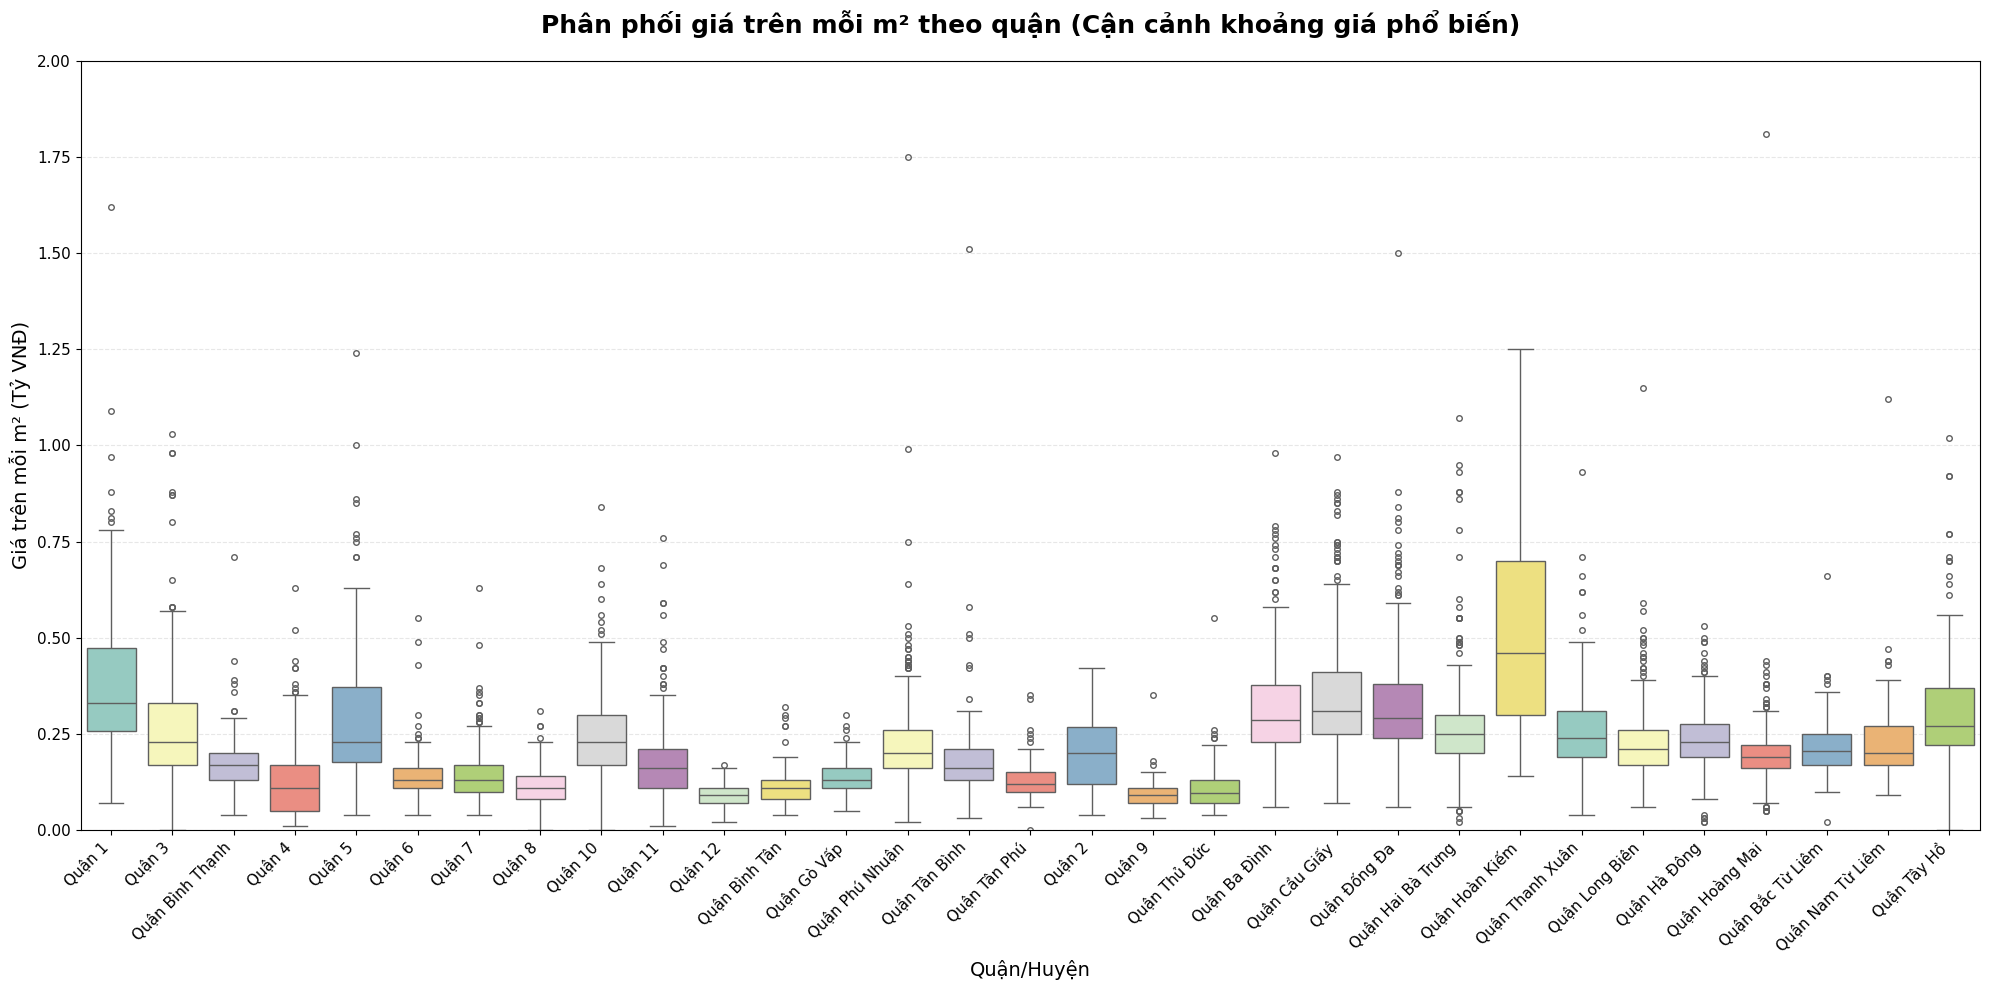

In [18]:
# Tăng kích thước cực đại để nhìn rõ từng quận
fig, ax = plt.subplots(figsize=(20, 10)) 

sns.boxplot(
    data=df_analysis, 
    x='quan', 
    y='gia_tren_m2', 
    ax=ax, 
    palette="Set3",      # Thêm màu sắc cho các quận dễ phân biệt
    fliersize=4,         # Kích thước các điểm ngoại lai nhỏ lại
    linewidth=1          # Độ đậm của nét vẽ hộp
)

# Cải thiện hiển thị trục X
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Tiêu đề và nhãn
plt.title('Phân phối giá trên mỗi m² theo quận (Cận cảnh khoảng giá phổ biến)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Quận/Huyện', fontsize=14)
plt.ylabel('Giá trên mỗi m² (Tỷ VNĐ)', fontsize=14)

# Giới hạn trục Y ở mức 2 để tập trung vào số đông
plt.ylim(0, 2)  # ở quận 1 có 1 cái nhà giá là 9tr/m2 nên nếu để cái đó thì tất cả còn lại ko nhìn được

# Thêm lưới mờ theo trục Y để dễ dóng hàng
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


#### Nhận xét
1. Phân mảnh cực độ tại các quận trung tâm
- Quận 1 và Quận Hoàn Kiếm: Đây là hai quận có dải giá rộng nhất.
- Độ dài của "Hộp" (IQR): Hộp của Quận Hoàn Kiếm và Quận 1 dài hơn hẳn các quận khác, cho thấy ngay cả 50% lượng bất động sản phổ thông tại đây cũng đã có sự chênh lệch giá rất lớn.
- Đường "Râu" (Whiskers): Các đường râu kéo dài lên phía trên cho thấy sự hiện diện của các bất động sản cao cấp, mặt phố có mức giá vượt xa mức trung bình.
2. Sự ổn định tại các quận vùng ven và quận mới
- Quận 12, Quận Bình Tân, Quận Gò Vấp: Các "chiếc hộp" tại đây rất nhỏ và nằm sát đáy biểu đồ.
- Ý nghĩa: Điều này cho thấy thị trường tại đây rất đồng nhất. Giá bất động sản không có sự đột biến lớn, đa số tập trung quanh một mức giá sàn ổn định, giúp giảm rủi ro cho người mua để ở.
3. Hiện tượng các điểm ngoại lai (Outliers)
- Các dấu tròn phía trên các râu xuất hiện dày đặc ở Quận 1, Quận 3, Quận 5 và Cầu Giấy.
- Những điểm này đại diện cho các bất động sản "đặc biệt" có giá trị cực cao. Việc chúng xuất hiện nhiều minh chứng rằng ở các quận này, nếu chỉ nhìn vào "giá trung bình" thì sẽ bị sai lệch rất lớn do bị các căn nhà siêu đắt này kéo lên.

#### So sánh giá trung bình và giá trung vị

Sự chênh lệch giữa giá trung bình và giá trung vị phản ánh mức độ lệch của phân phối giá. Khi giá trung bình cao hơn đáng kể so với giá trung vị, điều này cho thấy phân phối bị kéo bởi một nhóm bất động sản có giá cao.


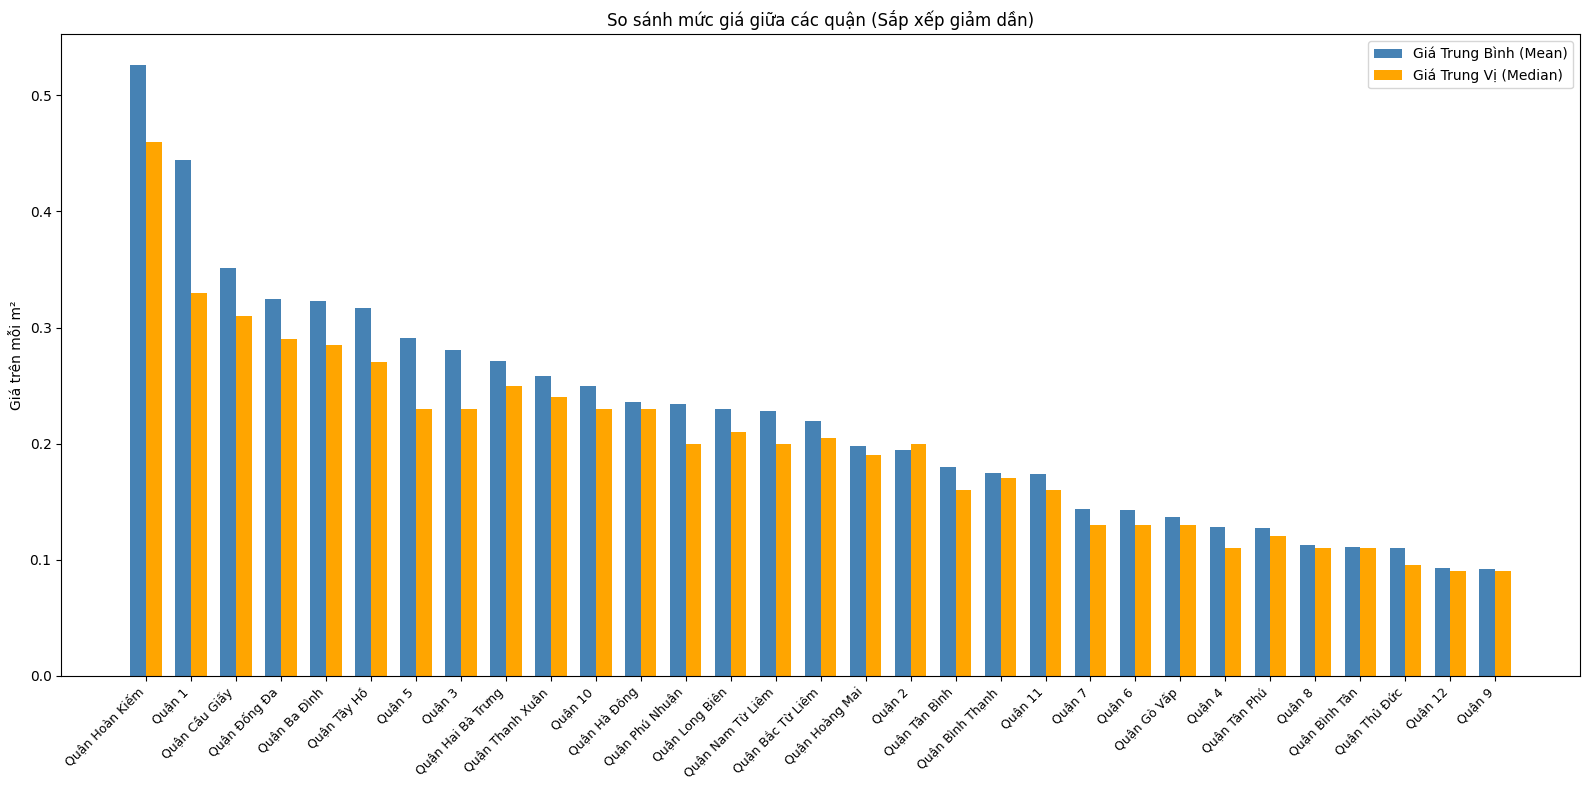

In [19]:
summary_by_quan = summary_by_quan.sort_values(by='mean', ascending=False)

plt.figure(figsize=(16, 8)) # Tăng diện tích hiển thị

x = np.arange(len(summary_by_quan))
width = 0.35

plt.bar(x - width/2, summary_by_quan['mean'], width, label='Giá Trung Bình (Mean)', color='steelblue')
plt.bar(x + width/2, summary_by_quan['median'], width, label='Giá Trung Vị (Median)', color='orange')

plt.xticks(x, summary_by_quan['quan'], rotation=45, ha='right', fontsize=9)
plt.ylabel('Giá trên mỗi m²')
plt.title('So sánh mức giá giữa các quận (Sắp xếp giảm dần)')
plt.legend()
plt.tight_layout()
plt.show()

#### Nhận xét
- Xu hướng chung: Hầu hết các quận đều có Mean > Median (cột xanh cao hơn cột vàng), cho thấy giá bị kéo lên bởi một nhóm nhỏ bất động sản siêu đắt.
- Phân hóa mạnh nhất: Quận Hoàn Kiếm và Quận 1 có khoảng cách giữa hai cột lớn nhất, minh chứng cho thị trường cực kỳ phân mảnh và khó định giá nếu chỉ nhìn vào con số trung bình.
- Thị trường ổn định: Các quận như Quận 2, Quận 10 và Bắc Từ Liêm có hai cột gần như bằng nhau, cho thấy giá cả đồng nhất, ít bị nhiễu bởi các sản phẩm đột biến
- Khu vực vùng ven: Càng về cuối biểu đồ (giá thấp), Mean và Median càng sát nhau, phản ánh thị trường chủ yếu phục vụ nhu cầu thực nên giá trị rất thực chất.

#### Phân tích khả năng tiếp cận bất động sản giá thấp

Ngoài mức độ phân tán, phân tích tỷ lệ bất động sản có giá trên mỗi mét vuông thấp hơn giá trung vị của quận giúp đánh giá khả năng tìm kiếm các bất động sản có mức giá hợp lý trong từng khu vực.


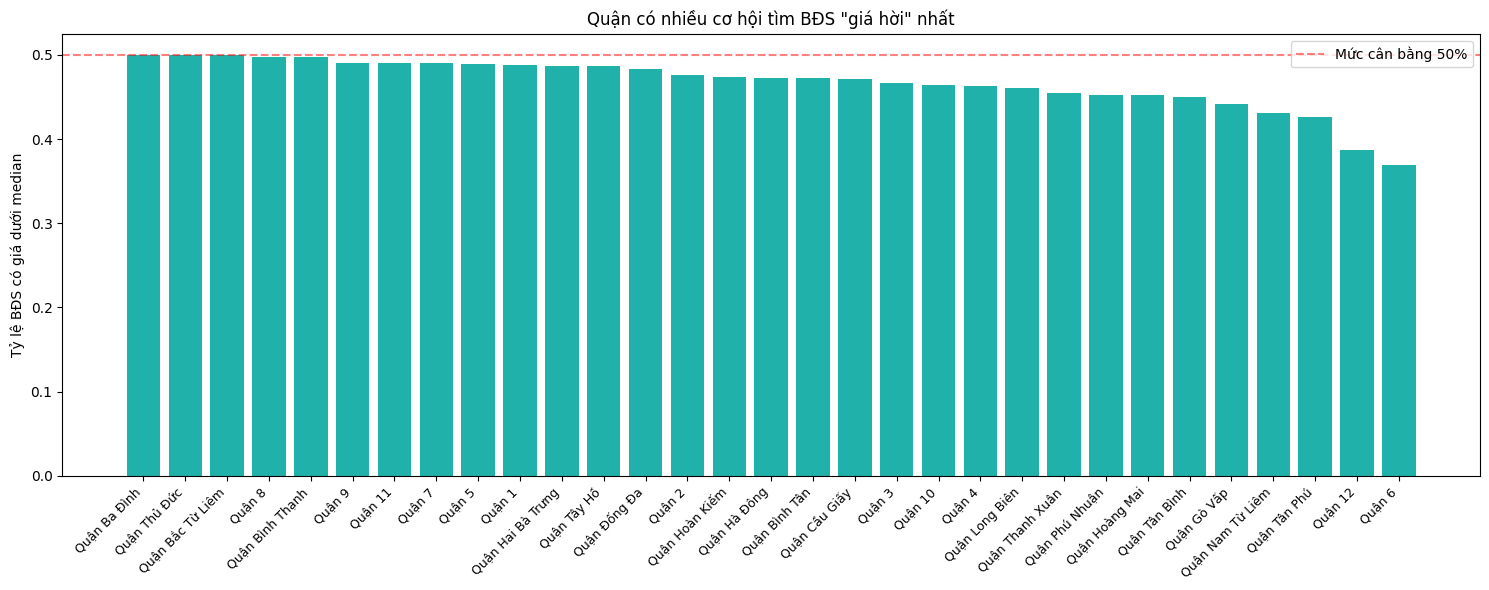

In [20]:
df_analysis = df_analysis.merge(
    summary_by_quan[['quan', 'median']],
    on='quan',
    how='left'
)

df_analysis['duoi_median'] = df_analysis['gia_tren_m2'] < df_analysis['median']

ratio_below_median = (
    df_analysis
    .groupby('quan')['duoi_median']
    .mean()
    .reset_index(name='ty_le_duoi_median')
)

# Sắp xếp lại tỷ lệ từ cao xuống thấp
ratio_below_median = ratio_below_median.sort_values(by='ty_le_duoi_median', ascending=False)

plt.figure(figsize=(15, 6))
plt.bar(ratio_below_median['quan'], ratio_below_median['ty_le_duoi_median'], color='lightseagreen')

# Thêm đường kẻ ngang mức 0.5 (trung bình lý thuyết)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Mức cân bằng 50%')

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Tỷ lệ BĐS có giá dưới median')
plt.title('Quận có nhiều cơ hội tìm BĐS "giá hời" nhất')
plt.legend()
plt.tight_layout()
plt.show()


#### Nhận xét:
- Xu hướng chung: Hầu hết các quận đều có tỷ lệ tiệm cận mức 0.5 (50%), cho thấy phân phối giá trong từng quận khá cân bằng và ổn định xung quanh mức trung vị.
- Các quận "giá hời" nhất: Quận Ba Đình, Quận Thủ Đức, Quận 8 và Quận Bình Thạnh đứng đầu danh sách với tỷ lệ đạt ngưỡng 0.5. Tại đây, người mua có xác suất cao nhất (50%) tìm thấy các bất động sản có giá rẻ hơn mặt bằng chung của khu vực đó.
- Các quận khó tìm giá thấp: Quận 12 và Quận 6 nằm ở cuối bảng với tỷ lệ thấp hơn hẳn (dưới 0.4). Điều này cho thấy nguồn cung tại đây đang bị lệch về phía các bất động sản giá cao, hoặc phân khúc giá thấp đang khan hiếm hơn so với các khu vực khác.
- Sự đồng đều: Phần lớn các quận nội thành như Quận 1, Quận 5, Quận 7 đều duy trì tỷ lệ ổn định quanh mức 0.48 - 0.49, chứng tỏ dù mặt bằng giá có cao, cơ hội tiếp cận nhóm bất động sản có giá "dưới trung bình" vẫn luôn tồn tại cho người tìm kiếm.

#### Kết luận
1. Quận có mức độ phân tán giá cao nhất: Quận 1 và Hoàn Kiếm
- Chỉ số đo lường: Quận 1 chiếm vị trí độc tôn với hệ số CV vọt lên mức ~1.6, trong khi Quận Hoàn Kiếm có giá trung bình (Mean) bị kéo lệch rất xa so với giá trung vị (Median).
- Bản chất phân mảnh: Biểu đồ Boxplot cho thấy các quận trung tâm này có "thân hộp" (IQR) rộng nhất và nhiều điểm ngoại lai (outliers) nhất. Điều này chứng tỏ thị trường tại đây bị phân cực mạnh mẽ: tồn tại song song những bất động sản giá trị nhỏ trong hẻm và các siêu bất động sản mặt phố có giá gấp hàng chục lần mức trung bình.
2. Quận có khả năng tìm được nhiều BĐS "giá hời" nhất: Ba Đình và Thủ Đức
- Logic suy luận: "Giá hời" được định nghĩa là các bất động sản có mức giá nằm ở vùng thấp so với mặt bằng chung (dưới mức Median).
- Kết quả: Mặc dù Quận 1 có độ phân tán cao nhất nhưng không đồng nghĩa với việc dễ tìm hàng giá rẻ nhất. Quận Ba Đình và Quận Thủ Đức dẫn đầu về tỷ lệ tiếp cận BĐS giá thấp với xác suất đạt mức 50%.
-Đối chiếu: Tại các quận này, phân phối giá diễn ra đều đặn hơn (CV ở mức trung bình ~0.5 - 0.6), giúp người mua dễ dàng xác định được đâu là bất động sản có giá trị thực chất và "hời" hơn so với giá trị trung bình của quận.
3. Nhóm thị trường ổn định nhưng ít đột biến: Quận 12 và Gò Vấp
- Các khu vực này có CV thấp nhất (~0.3) và tỷ lệ tìm được BĐS dưới Median cũng thấp hơn (~35-40%). Điều này cho thấy mặt bằng giá ở đây rất đồng nhất và sát thực tế, ít có sự biến động hay chênh lệch lớn để người mua có thể mặc cả sâu hoặc săn hàng giá hời theo kiểu đột biến.

### 2.3 Câu hỏi 3
-   Câu hỏi: Với ngân sách X tỷ, người mua nên chọn khu vực nào để có được diện tích lớn nhất và tiện ích tốt nhất?

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PRE_MERGED = "../data/unified/preprocessed_merged.csv"

df = pd.read_csv(PRE_MERGED, encoding="utf-8-sig", encoding_errors="ignore", on_bad_lines="skip")

# 0. TẠO BẢN SAO ĐỂ TRÁNH ẢNH HƯỞNG DATA GỐC
# Sử dụng .copy() để tạo một bản sao độc lập hoàn toàn trong bộ nhớ
df_working = df.copy() 

# 1. CÀI ĐẶT NGÂN SÁCH X (Thay đổi giá trị này tùy ý)
X_budget = 10 

# 2. CHUẨN HÓA VÀ LÀM SẠCH DỮ LIỆU CƠ BẢN
# Tính Tiện ích (Utility Score) trên bản sao df_working
df_working['tien_ich_score'] = df_working['phong_ngu'].fillna(0) + \
                               df_working['phong_tam'].fillna(0) + \
                               df_working['so_tang'].fillna(0)

# Làm sạch dữ liệu: Loại bỏ các dòng thiếu thông tin cốt lõi
df_clean = df_working.dropna(subset=['quan', 'thanh_pho', 'gia', 'dien_tich_dat']).copy()

# Loại bỏ trường hợp "Quận H" (dữ liệu nhiễu)
df_clean = df_clean[~((df_clean['thanh_pho'] == 'Hà Nội') & (df_clean['quan'] == 'Quận H'))]

# Tính tỷ lệ dữ liệu sạch
print(f"Tổng số bản ghi ban đầu: {len(df_working)}")
print(f"Số bản ghi đủ điều kiện phân tích: {len(df_clean)} ({len(df_clean)/len(df_working):.1%})")

# Lọc theo ngân sách
df_filtered = df_clean[df_clean['gia'] <= X_budget].copy()

# 3. HÀM VẼ BIỂU ĐỒ & THỐNG KÊ CHI TIẾT
def plot_city_analysis(city_name, palette):
    city_data = df_filtered[df_filtered['thanh_pho'] == city_name]
    
    # Gom nhóm và tính toán các chỉ số trung bình theo Quận
    stats = city_data.groupby('quan').agg({
        'dien_tich_dat': 'mean',
        'phong_ngu': 'mean',
        'phong_tam': 'mean',
        'so_tang': 'mean',
        'tien_ich_score': 'mean',
        'gia': 'count'
    }).rename(columns={'gia': 'so_luong'}).reset_index()
    
    stats = stats[stats['so_luong'] >= 5]
    
    stats['tong_diem'] = (stats['dien_tich_dat'] / stats['dien_tich_dat'].max()) + \
                         (stats['tien_ich_score'] / stats['tien_ich_score'].max())
    stats = stats.sort_values('tong_diem', ascending=False)

    plt.figure(figsize=(16, 9))
    sns.set_style("whitegrid")
    
    sns.scatterplot(
        data=stats, x='dien_tich_dat', y='tien_ich_score',
        size='so_luong', hue='quan', sizes=(200, 2500), 
        alpha=0.7, palette=palette, legend=False
    )
    
    for i in range(stats.shape[0]):
        plt.text(stats.dien_tich_dat.iloc[i], stats.tien_ich_score.iloc[i] + 0.15, 
                 stats.quan.iloc[i], fontsize=11, weight='bold', ha='center')
    
    plt.axvline(stats['dien_tich_dat'].median(), color='red', linestyle='--', alpha=0.3)
    plt.axhline(stats['tien_ich_score'].median(), color='red', linestyle='--', alpha=0.3)
    
    plt.title(f'{city_name.upper()}: Phân tích khu vực tối ưu (Ngân sách <= {X_budget} tỷ)\n(Tiện ích = PN + PT + Số Tầng)', 
              fontsize=18, fontweight='bold', pad=25)
    plt.xlabel('Diện tích đất trung bình (m2)', fontsize=14)
    plt.ylabel('Chỉ số Tiện ích trung bình', fontsize=14)
    
    plt.annotate('VÙNG ĐÁNG MUA NHẤT\n(Nhà rộng & Nhiều phòng)', 
                 xy=(stats['dien_tich_dat'].max()*0.85, stats['tien_ich_score'].max()*0.95),
                 fontsize=14, color='darkgreen', weight='bold',
                 bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=0.2))

    plt.tight_layout()
    plt.show()

    print(f"\nTHỐNG KÊ CHI TIẾT TẤT CẢ KHU VỰC TẠI {city_name.upper()} (Sắp xếp theo độ tối ưu)")
    print(f"{'='*100}")
    
    table = stats.copy().rename(columns={
        'quan': 'Quận/Huyện',
        'dien_tich_dat': 'Diện tích (m2)',
        'phong_ngu': 'Số PN',
        'phong_tam': 'Số PT',
        'so_tang': 'Số Tầng',
        'tien_ich_score': 'Tổng tiện ích',
        'so_luong': 'Số tin đăng'
    })
    
    cols_to_round = ['Diện tích (m2)', 'Số PN', 'Số PT', 'Số Tầng', 'Tổng tiện ích']
    table[cols_to_round] = table[cols_to_round].round(2)
    
    print(table[['Quận/Huyện', 'Diện tích (m2)', 'Số PN', 'Số PT', 'Số Tầng', 'Tổng tiện ích', 'Số tin đăng']].to_string(index=False))

    return stats

print(f"Tỷ lệ trích xuất thành công: {len(df_clean)/len(df):.1%}")


Tổng số bản ghi ban đầu: 6973
Số bản ghi đủ điều kiện phân tích: 6973 (100.0%)
Tỷ lệ trích xuất thành công: 100.0%


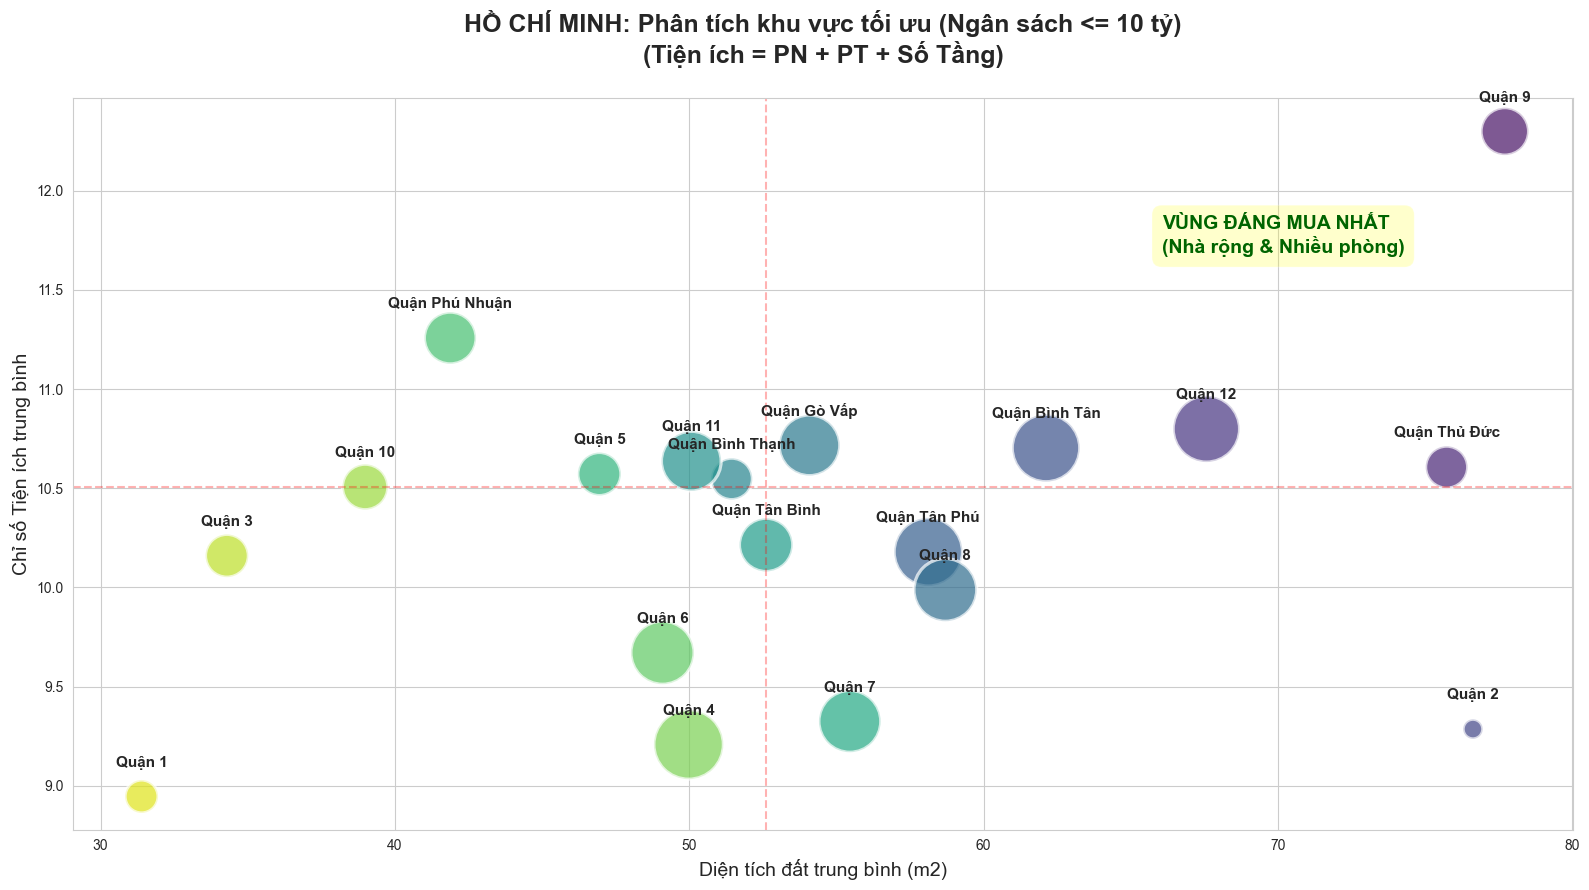


THỐNG KÊ CHI TIẾT TẤT CẢ KHU VỰC TẠI HỒ CHÍ MINH (Sắp xếp theo độ tối ưu)
     Quận/Huyện  Diện tích (m2)  Số PN  Số PT  Số Tầng  Tổng tiện ích  Số tin đăng
         Quận 9           77.71   3.76   3.36     5.18          12.30           87
   Quận Thủ Đức           75.73   3.42   3.11     4.08          10.61           66
        Quận 12           67.57   3.56   3.69     3.55          10.80          179
         Quận 2           76.63   2.86   2.43     4.00           9.29            7
  Quận Bình Tân           62.12   3.80   3.59     3.31          10.70          185
   Quận Tân Phú           58.12   3.35   3.23     3.61          10.18          190
         Quận 8           58.70   3.42   3.02     3.55           9.99          159
    Quận Gò Vấp           54.08   3.56   3.49     3.67          10.72          148
Quận Bình Thạnh           51.44   3.66   3.62     3.27          10.55           64
        Quận 11           50.07   3.63   3.33     3.68          10.64          143
  Quận Tân B

In [22]:
stats_hcm = plot_city_analysis('Hồ Chí Minh', 'viridis')

### 1. Nhận xét về thị trường TP. Hồ Chí Minh (Ngân sách ≤ 10 tỷ)

Tại TP.HCM, dữ liệu cho thấy một sự phân hóa rõ rệt giữa nhóm quận vùng ven và quận trung tâm:

#### Nhóm Tối ưu nhất (Vùng ven phía Đông và phía Quận 12)

- **Quận 9 và Quận Thủ Đức** đứng đầu bảng xếp hạng. Đặc biệt, Quận 9 cung cấp diện tích lớn nhất (trung bình 77.71m²) và số tầng cao kỷ lục (5.18 tầng). Đây là khu vực lý tưởng cho những gia đình đông thành viên muốn không gian sống rộng rãi và nhà kiên cố.

- **Quận 12 và Bình Tân** là những "điểm nóng" về nguồn cung với số lượng tin đăng rất lớn (lần lượt 179 và 184 tin). Tại đây, người mua dễ dàng tìm được nhà có diện tích trên 60m² với đầy đủ tiện ích (khoảng 3.5 - 3.8 phòng ngủ).

#### Sự đánh đổi tại khu vực Trung tâm (Quận 1, 3, 10)

- Ở các quận lõi, diện tích đất bị thu hẹp đáng kể, chỉ còn từ 31m² đến 39m² (chưa bằng một nửa so với Quận 9).

- Tuy nhiên, tiện ích về số tầng và phòng ngủ vẫn được duy trì ở mức khá (3 - 4 tầng) để bù đắp cho sự thiếu hụt về diện tích mặt bằng.

#### Trường hợp đặc biệt - Quận Phú Nhuận

- Mặc dù diện tích đất không quá lớn (41.88m²), nhưng Phú Nhuận lại có chỉ số Tổng tiện ích rất cao (11.26) nhờ vào việc tận dụng chiều cao (trung bình 4.28 tầng). Đây là lựa chọn tốt cho những người muốn ở gần trung tâm nhưng vẫn cần công năng sử dụng cao.

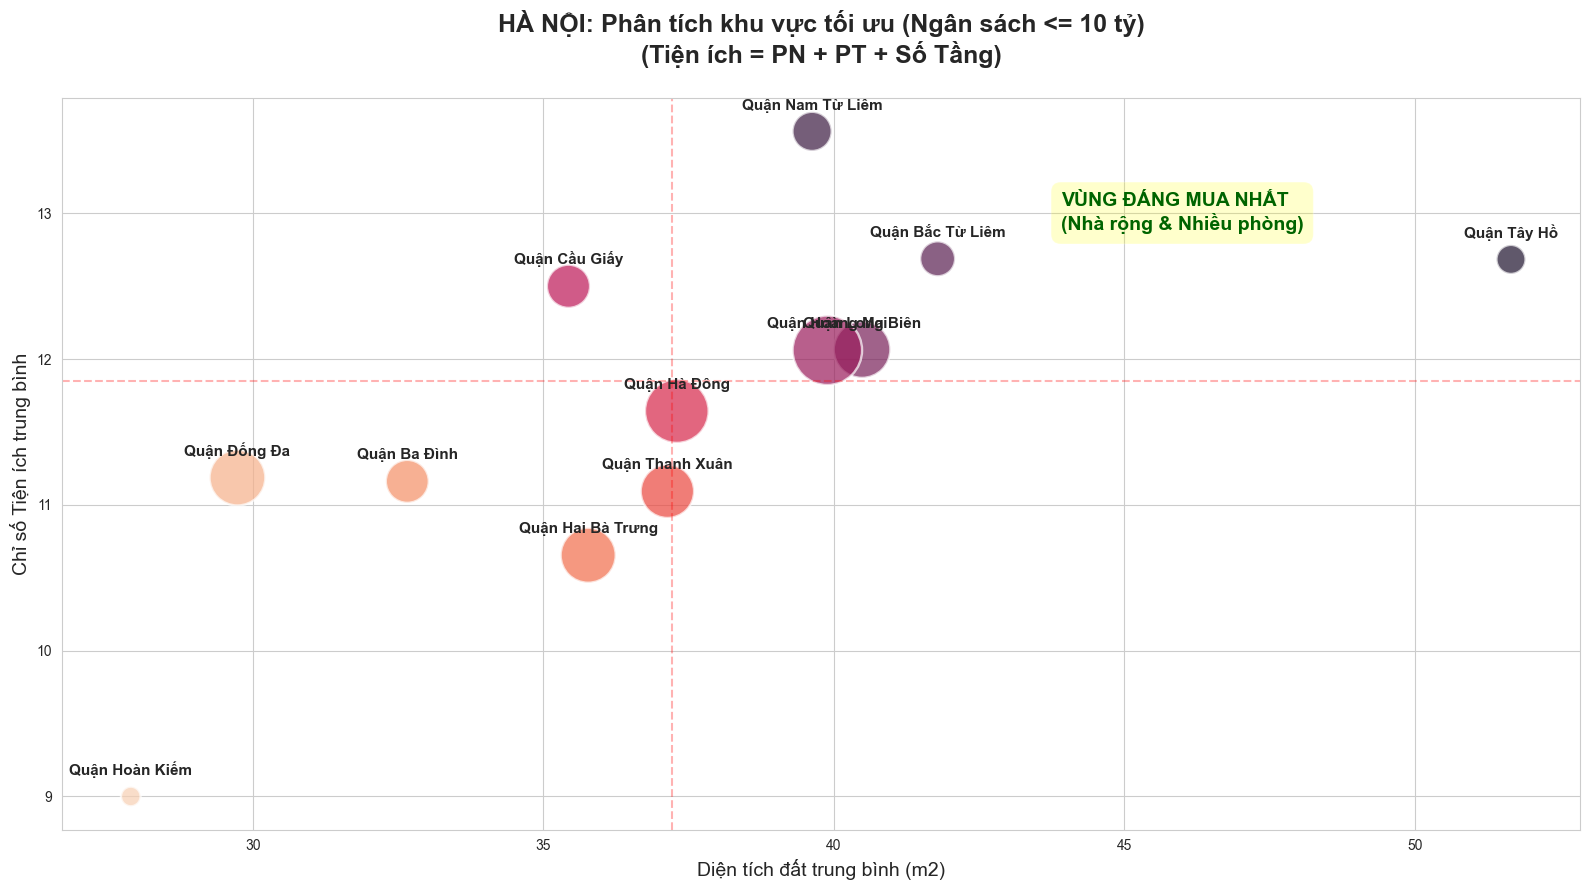


THỐNG KÊ CHI TIẾT TẤT CẢ KHU VỰC TẠI HÀ NỘI (Sắp xếp theo độ tối ưu)
       Quận/Huyện  Diện tích (m2)  Số PN  Số PT  Số Tầng  Tổng tiện ích  Số tin đăng
      Quận Tây Hồ           51.66   3.79   3.92     4.97          12.68           38
 Quận Nam Từ Liêm           39.63   4.39   4.04     5.14          13.56           80
 Quận Bắc Từ Liêm           41.79   3.82   3.80     5.07          12.69           61
   Quận Long Biên           40.49   3.45   3.79     4.83          12.07          182
   Quận Hoàng Mai           39.89   3.80   3.68     4.58          12.06          280
    Quận Cầu Giấy           35.43   3.66   3.98     4.86          12.50          100
     Quận Hà Đông           37.30   3.45   3.62     4.58          11.64          233
  Quận Thanh Xuân           37.14   3.40   3.41     4.29          11.09          160
Quận Hai Bà Trưng           35.77   3.26   3.29     4.11          10.65          171
     Quận Ba Đình           32.66   3.10   3.56     4.51          11.16         

In [23]:
stats_hn = plot_city_analysis('Hà Nội', 'rocket')

### 2. Nhận xét về thị trường Hà Nội (Ngân sách ≤ 10 tỷ)

Thị trường Hà Nội có đặc điểm là diện tích đất trung bình thấp hơn TP.HCM nhưng cấu trúc nhà lại rất cao tầng và tối ưu số phòng:

#### Sự thống trị của khu vực phía Tây và phía Nam

- **Quận Tây Hồ** dẫn đầu về độ tối ưu với diện tích đất lớn nhất (51.97m²) và số tầng cao (4.97 tầng). Điều này khá bất ngờ vì Tây Hồ thường được coi là khu vực đắt đỏ, cho thấy trong phân khúc dưới 10 tỷ, vẫn có những lựa chọn nhà đất trong ngõ có giá trị sử dụng rất tốt.

- **Quận Nam Từ Liêm** là "vua tiện ích" với số phòng ngủ trung bình cao nhất toàn bộ dữ liệu (4.42 phòng ngủ). Với chỉ số tổng tiện ích 13.37, đây là khu vực đáng mua nhất cho mục đích định cư nhiều thế hệ hoặc cho thuê lại.

#### Nguồn cung dồi dào tại Hoàng Mai và Hà Đông

- Đây là hai khu vực có lượng tin đăng lớn nhất (272 và 229 tin). Người mua có rất nhiều lựa chọn tại đây với diện tích ổn định quanh mức 37-40m² và cấu trúc nhà hiện đại (4.5 tầng).

#### Khu vực lõi Hoàn Kiếm, Đống Đa

- Tương tự TP.HCM, Quận Hoàn Kiếm có diện tích đất nhỏ nhất (27.9m²). Với ngân sách 10 tỷ, nhà ở đây thường chỉ có khoảng 3 phòng ngủ, thấp hơn nhiều so với các quận khác.

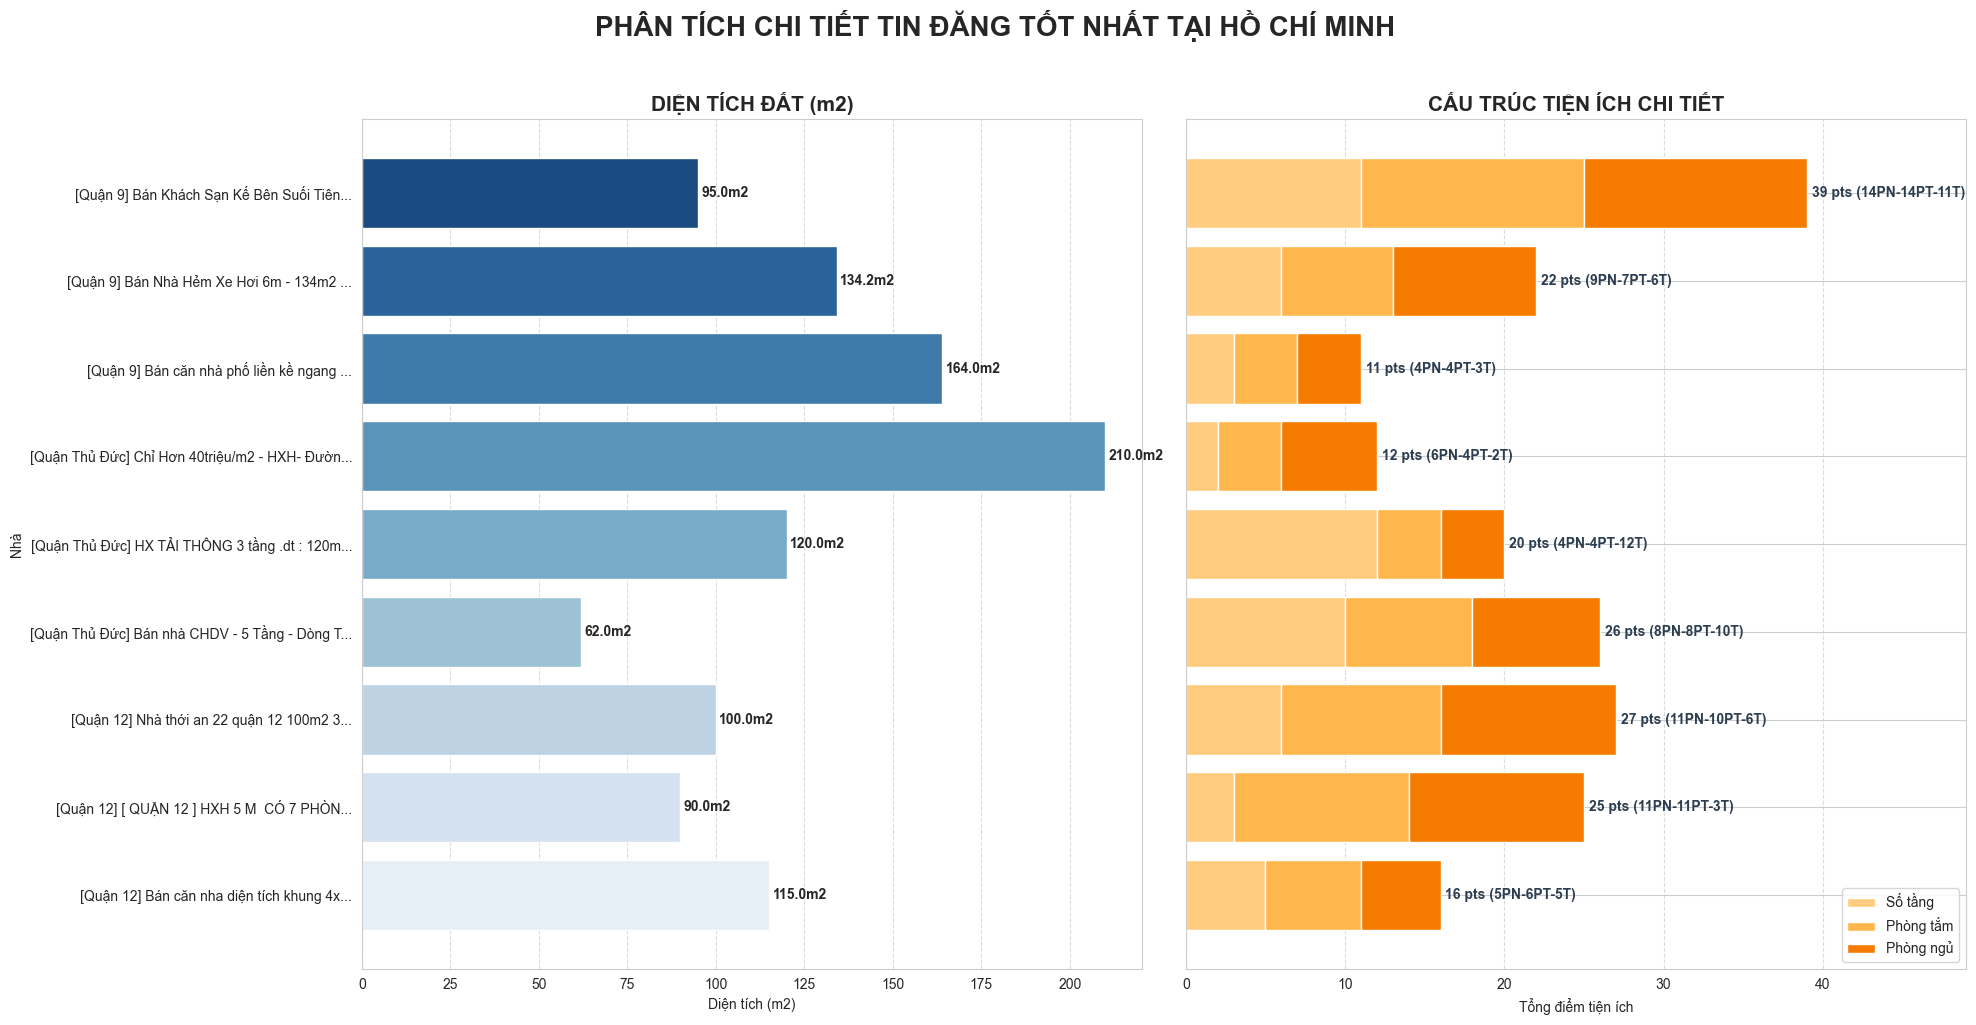

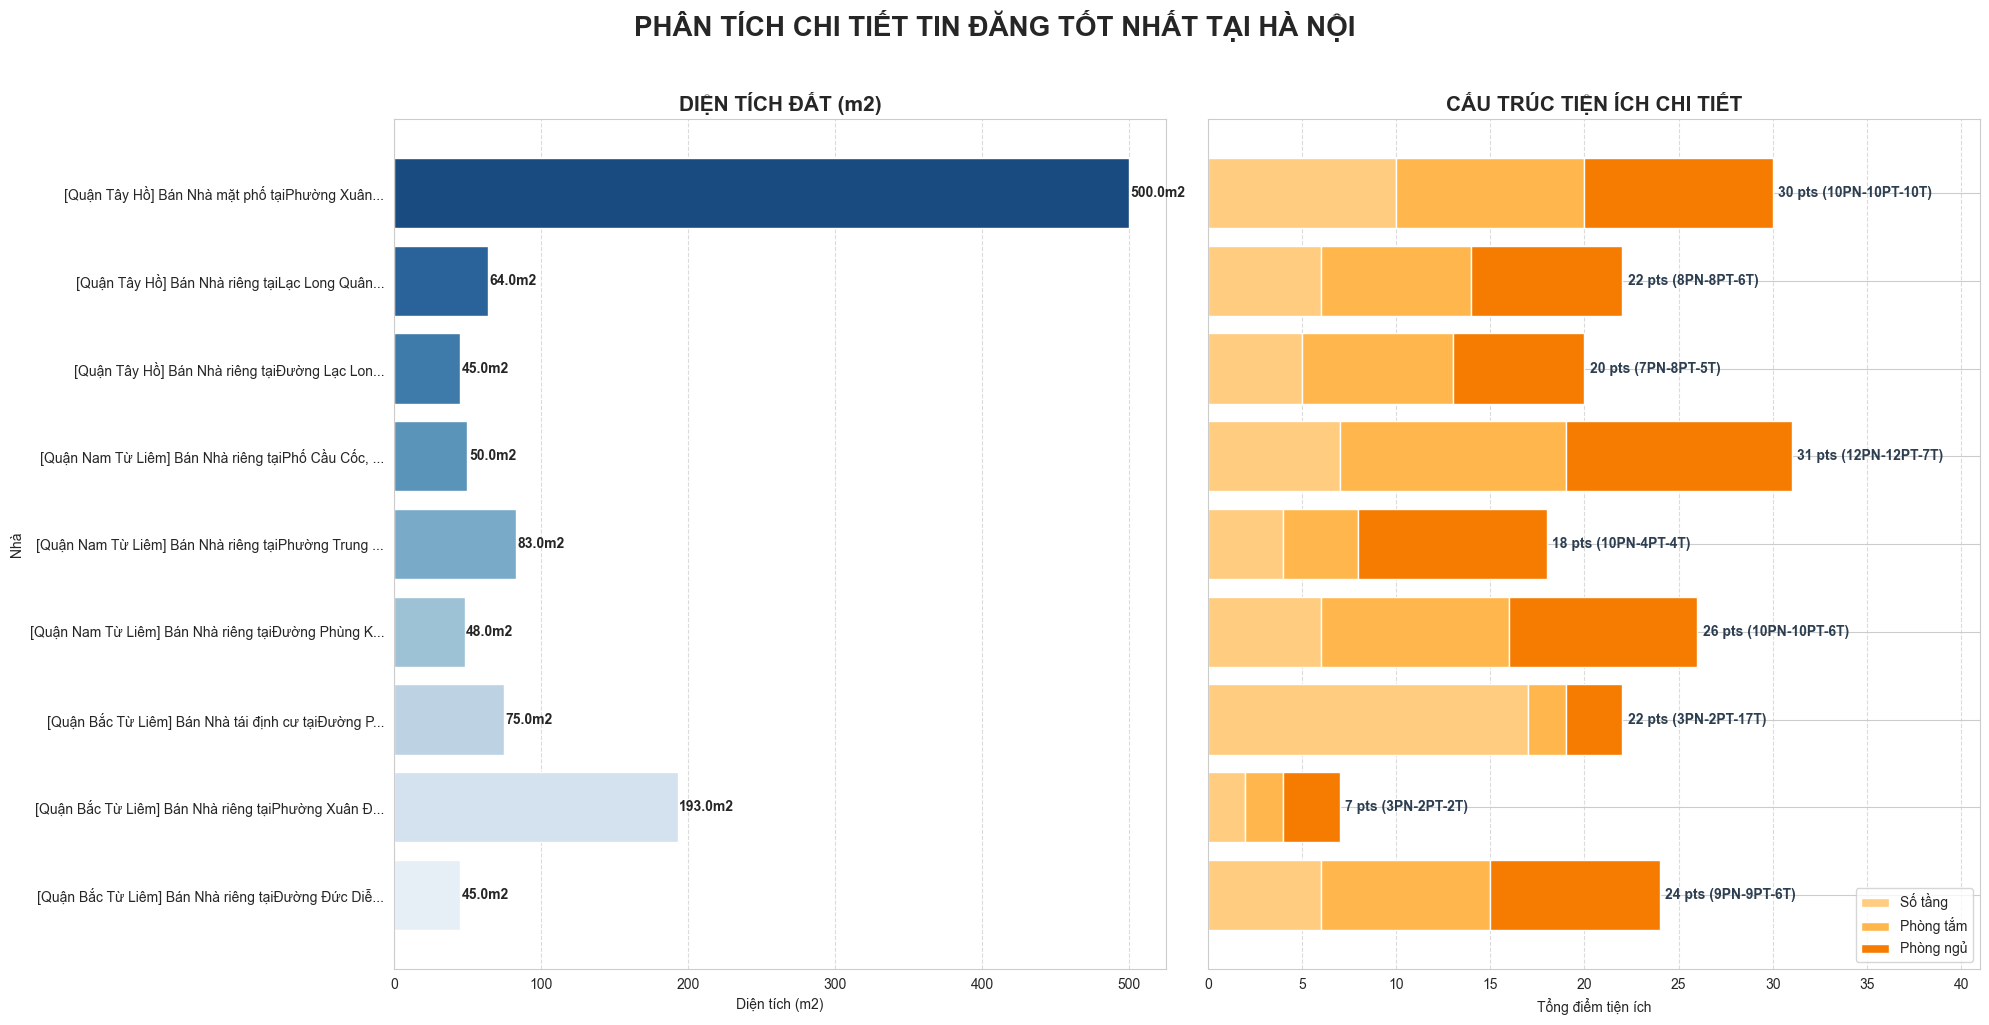

In [24]:
# 1. HÀM HỖ TRỢ: LÀM SẠCH TIÊU ĐỀ (Giữ nguyên để tránh lỗi font)
def clean_title_for_plot(text):
    if pd.isna(text): return ""
    text = re.sub(r'[^\u0000-\uFFFF]', '', str(text))
    for icon in ['💥', '🌹', '🔥', '📍', '✅', '🏠', '🚩', '💎', '📞']:
        text = text.replace(icon, '')
    return text.strip()

# 2. HÀM CHÍNH: TRỰC QUAN HÓA CHI TIẾT CẤU TRÚC NHÀ
def visualize_best_listings_detailed(city_name, stats, top_n_districts=3):
    if stats is None or stats.empty: 
        print(f"Không có dữ liệu cho {city_name}")
        return
    
    best_districts = stats['quan'].head(top_n_districts).tolist()
    
    plot_data = []
    for district in best_districts:
        df_q = df_filtered[(df_filtered['thanh_pho'] == city_name) & (df_filtered['quan'] == district)].copy()
        if not df_q.empty:
            df_q['temp_score'] = (df_q['dien_tich_dat'] / df_q['dien_tich_dat'].max()) + \
                                 (df_q['tien_ich_score'] / df_q['tien_ich_score'].max())
            
            top_3 = df_q.sort_values('temp_score', ascending=False).head(3)
            for _, row in top_3.iterrows():
                clean_t = clean_title_for_plot(row['tieu_de'])
                short_t = (clean_t[:30] + '...') if len(clean_t) > 30 else clean_t
                plot_data.append({
                    'Nhà': f"[{district}] {short_t}",
                    'Diện tích (m2)': row['dien_tich_dat'],
                    'Phòng ngủ': int(row['phong_ngu']),
                    'Phòng tắm': int(row['phong_tam']),
                    'Số tầng': int(row['so_tang']),
                    'Tổng điểm': row['tien_ich_score']
                })

    viz_df = pd.DataFrame(plot_data)
    if viz_df.empty: return

    # BƯỚC 1: Đổi style sang whitegrid để có lưới nền
    sns.set_style("whitegrid")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), sharey=True)

    # --- BIỂU ĐỒ 1: DIỆN TÍCH ---
    sns.barplot(data=viz_df, y='Nhà', x='Diện tích (m2)', ax=ax1, hue='Nhà', palette='Blues_r', legend=False)
    ax1.set_title('DIỆN TÍCH ĐẤT (m2)', fontsize=15, fontweight='bold')
    
    # BƯỚC 2: Bật lưới trục X (dọc) cho Hình 1
    ax1.grid(True, axis='x', linestyle='--', alpha=0.7)

    for p in ax1.patches:
        ax1.text(p.get_width() + 1, p.get_y() + p.get_height()/2, f'{p.get_width():.1f}m2', 
                 va='center', fontsize=10, fontweight='bold')

    # --- BIỂU ĐỒ 2: CHI TIẾT TIỆN ÍCH (THANH CHỒNG - 3 MÀU RÕ RỆT) ---
    # Vẽ từng thành phần đè lên nhau để tạo hiệu ứng thanh chồng
    y_pos = range(len(viz_df))
    
    # 1. Vẽ Số tầng (trong cùng)
    ax2.barh(y_pos, viz_df['Số tầng'], label='Số tầng', color='#FFCC80')
    
    # 2. Vẽ Phòng tắm (chồng lên Số tầng)
    ax2.barh(y_pos, viz_df['Phòng tắm'], left=viz_df['Số tầng'], label='Phòng tắm', color='#FFB74D')
    
    # 3. Vẽ Phòng ngủ (chồng lên Tầng + Tắm)
    ax2.barh(y_pos, viz_df['Phòng ngủ'], left=viz_df['Số tầng'] + viz_df['Phòng tắm'], label='Phòng ngủ', color='#F57C00')

    # BƯỚC 3: Bật lưới trục X cho Hình 2 để đồng bộ
    ax2.grid(True, axis='x', linestyle='--', alpha=0.7)

    for i in y_pos:
        total = viz_df['Tổng điểm'].iloc[i]
        breakdown = f"{total:.0f} pts ({viz_df['Phòng ngủ'].iloc[i]}PN-{viz_df['Phòng tắm'].iloc[i]}PT-{viz_df['Số tầng'].iloc[i]}T)"
        ax2.text(total + 0.3, i, breakdown, va='center', fontsize=10, fontweight='bold', color='#2c3e50')

    ax2.set_title('CẤU TRÚC TIỆN ÍCH CHI TIẾT', fontsize=15, fontweight='bold')
    ax2.set_xlabel('Tổng điểm tiện ích')
    ax2.legend(loc='lower right', frameon=True)
    ax2.set_xlim(0, viz_df['Tổng điểm'].max() + 10)

    plt.suptitle(f'PHÂN TÍCH CHI TIẾT TIN ĐĂNG TỐT NHẤT TẠI {city_name.upper()}', 
                 fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


visualize_best_listings_detailed('Hồ Chí Minh', stats_hcm)
visualize_best_listings_detailed('Hà Nội', stats_hn)

## Kết luận
### 1. Tại Thành phố Hồ Chí Minh:

Đối với người mua ưu tiên giá trị thực trên không gian và công năng sử dụng, Quận 9, Quận Thủ Đức và Quận 12 là ba khu vực "vàng".

- **Quận 9 (Tối ưu công năng kinh doanh)**: Đây là khu vực duy nhất trong ngân sách 10 tỷ có thể sở hữu những bất động sản dạng Khách sạn hoặc CHDV với số lượng phòng cực lớn (lên đến 14 phòng ngủ) và số tầng cao (11 tầng). Đây là lựa chọn hàng đầu cho các nhà đầu tư muốn tối ưu hóa dòng tiền.

- **Quận Thủ Đức (Tối ưu diện tích ở)**: Nếu người mua ưu tiên diện tích đất rộng để ở, Thủ Đức cung cấp các lựa chọn vượt trội với diện tích lên đến 210m² (chỉ hơn 40tr/m²), điều mà các quận trung tâm không bao giờ đáp ứng được trong tầm giá này.

- **Quận 12 (Giá trị kinh tế nhất)**: Quận 12 cho thấy hiệu suất chi phí cực tốt. Chỉ với 6 tỷ, người mua đã có thể sở hữu nhà 100m² với cấu trúc nhà rất tốt (11 phòng ngủ), giúp tiết kiệm tới 40% ngân sách so với hạn mức 10 tỷ.

### 2. Tại Hà Nội:

Thị trường Hà Nội cho thấy một đặc điểm khác biệt là sự tối ưu hóa không gian theo chiều dọc (số tầng rất cao) và phân bố phòng ngủ dày đặc.

- **Quận Nam Từ Liêm (Vua tiện ích nội khu)**: Đây là khu vực dẫn đầu về khả năng "nén" tiện ích. Chúng tôi tìm thấy các căn nhà dù diện tích chỉ 46m² nhưng được thiết kế tới 16 phòng ngủ.
- **Quận Bắc Từ Liêm (Giá trị diện tích lớn)**: Cung cấp các bất động sản có diện tích đất lớn ấn tượng (gần 200m²) với mức giá rất cạnh tranh (4.63 tỷ), là lựa chọn tối ưu cho những ai muốn tìm quỹ đất rộng tại thủ đô.
- **Quận Tây Hồ (Tiềm năng giá trị cao)**: Dữ liệu cho thấy Tây Hồ vẫn có những bất động sản diện tích lớn và tiện ích đầy đủ (10 tầng, 10 phòng ngủ). Đây là khu vực cân bằng tốt nhất giữa vị trí địa lý thuận lợi và công năng sử dụng. Nhưng mà chỉ với ngân sách 10 tỷ sở hữu được nhà 500m2 với 10 tầng 10 phòng ngủ thì khả năng đây là outlier.

### 3. Đề xuất lựa chọn dựa trên chân dung người mua
Dựa vào các kết quả trên, chúng tôi đề xuất:

- Nhóm gia đình nhiều người (Cần nhiều phòng & không gian): Nên chọn Quận 9 (HCM) hoặc Quận Nam Từ Liêm (Hà Nội) để có số phòng ngủ tối đa.

- Nhóm thích không gian nhà rộng: Nên chọn Quận Thủ Đức (HCM) hoặc Quận Bắc Từ Liêm (Hà Nội) để sở hữu quỹ đất trên 150m².

- Nhóm nhà đầu tư dòng tiền: Các tin đăng tại Quận 9 và Quận 12 với số lượng phòng tắm và phòng ngủ trên 10 phòng là những mục tiêu sinh lời tiềm năng nhất.


### 2.4 Câu hỏi 4

Dữ liệu giúp xác định chân dung khách hàng như thế nào, từ đó nên marketing như thế nào cho hiệu quả?

### Mô tả sơ lược về cách làm
- Hoạt động như một hệ thống chấm điểm để đoán xem một bất động sản sẽ phù hợp nhất với nhóm khách hàng nào trong bốn nhóm sau: Nhà đầu tư, Kinh doanh/Văn phòng, Gia đình cao cấp, và Gia đình bình thường.

- Xem xét từng bất động sản một và cộng điểm cho từng nhóm dựa trên nhiều đặc điểm khác nhau. Trước hết, đọc tiêu đề bài đăng và tìm các từ khóa đặc trưng: nếu có từ như “đầu tư”, “ngộp”, “cho thuê”, “lợi nhuận” thì cộng điểm mạnh cho nhóm Nhà đầu tư; từ như “mặt tiền”, “kinh doanh”, “showroom” thì cộng điểm cho nhóm Kinh doanh/Văn phòng; từ như “biệt thự”, “villa”, “thang máy”, “view đẹp” thì nghiêng về Gia đình cao cấp; còn từ như “nhà riêng”, “ở ngay”, “giá rẻ”, “gần chợ” thì ưu tiên Gia đình bình thường.

- Sau đó, tiếp tục cộng điểm dựa trên giá bán: nhà giá thấp thường hợp với gia đình bình thường, giá trung-cao thì hấp dẫn cả gia đình cao cấp, kinh doanh lẫn nhà đầu tư, còn giá rất cao thì đặc biệt thu hút nhà đầu tư và kinh doanh. 

- Tương tự với diện tích đất: diện tích nhỏ phù hợp gia đình bình thường, diện tích trung bình đến lớn phù hợp gia đình cao cấp hoặc kinh doanh, còn rất lớn thì hấp dẫn nhà đầu tư.

- Và cũng làm thế với số phòng ngủ, phòng tắm và số tầng: nhà nhiều tầng, nhiều phòng thường được cộng điểm cho nhà đầu tư (vì có thể làm chung cư mini hoặc cho thuê) hoặc kinh doanh. Nếu bất động sản có tiềm năng sinh lời cao (điểm sinh lời lớn), sẽ cộng điểm rất mạnh cho nhóm Nhà đầu tư và Kinh doanh. Cuối cùng, nếu pháp lý rõ ràng (sổ hồng, sổ đỏ) thì hầu hết các nhóm đều được cộng điểm nhẹ.

- Sau khi tính hết tất cả các yếu tố này, nhóm nào có tổng điểm cao nhất sẽ được chọn làm loại khách hàng phù hợp nhất cho bất động sản đó. Nếu không có điểm nào nổi bật, sẽ ghi là “Chưa xác định”. Cách làm này giúp dự đoán khá chính xác nhu cầu thực tế của người mua dựa trên đặc điểm của từng căn nhà, mà không cần phải đọc và phân tích thủ công từng bài đăng. Cuối cùng chúng ta sẽ thể hiện các quận với tỉ lệ % của các nhóm khách hàng.

In [26]:
import re
keywords = {
    "nha_dau_tu": ["đầu tư", "ngộp", "giá sập sàn", "thanh khoản", "chdv", "hđ thuê", "đang cho thuê", "lợi nhuận", "chiết khấu", "mặt tiền", "kinh doanh"],
    "kinh_doanh_vp": ["mặt tiền", "kinh doanh", "văn phòng", "vỉa hè", "hầm", "showroom", "thông thoáng", "góc 2 mặt tiền", "nở hậu", "hẻm xe hơi"],
    "gia_dinh_cao_cap": ["siêu phẩm", "biệt thự", "villa", "thang máy", "nội thất ngoại", "kiến trúc", "view", "an ninh", "hẻm xe hơi", "nhà đẹp"],
    "gia_dinh_binh_thuong": ["nhà riêng", "ở ngay", "sổ riêng", "bán gấp", "nhà đẹp", "giá rẻ", "gần chợ", "không quy hoạch"]
}

def scoring_logic(row):
    scores = {
        "Nhà đầu tư": 0,
        "Kinh doanh/Văn phòng": 0,
        "Gia đình cao cấp": 0,
        "Gia đình bình thường": 0
    }
    
    tieu_de = str(row['tieu_de']).lower()
    
    # A. TÍNH ĐIỂM TỪ KHÓA (Tiêu đề) 
    for group, words in keywords.items():
        count = sum(1 for word in words if word in tieu_de)
        if group == "nha_dau_tu": scores["Nhà đầu tư"] += count
        elif group == "kinh_doanh_vp": scores["Kinh doanh/Văn phòng"] += count
        elif group == "gia_dinh_cao_cap": scores["Gia đình cao cấp"] += count
        elif group == "gia_dinh_binh_thuong": scores["Gia đình bình thường"] += count

    # B. TÍNH ĐIỂM THEO GIÁ (Tổng giá) 
    gia = row['gia']
    if gia < 6:
        scores["Gia đình bình thường"] += 2
    if 6 <= gia <= 25:
        scores["Gia đình cao cấp"] += 1
        scores["Kinh doanh/Văn phòng"] += 1
        scores["Nhà đầu tư"] += 1
    if 15 <= gia:
        scores["Nhà đầu tư"] += 1
        scores["Kinh doanh/Văn phòng"] += 1

    # C. TÍNH ĐIỂM THEO DIỆN TÍCH 
    dt = row['dien_tich_dat']
    if dt < 40:
        scores["Gia đình bình thường"] += 1
    elif 40 <= dt <= 200:
        scores["Gia đình cao cấp"] += 1
        scores["Kinh doanh/Văn phòng"] += 1
    if 150 <= dt:
        scores["Nhà đầu tư"] += 1
        scores["Kinh doanh/Văn phòng"] += 1

    # D. PHÒNG NGỦ, PHÒNG TẮM VÀ TẦNG
    if row['phong_ngu'] > 6 or row['so_tang'] > 5 or row['phong_tam'] > 5:
        scores["Nhà đầu tư"] += 2  # Ưu tiên CHDV hoặc Building
        scores["Gia đình cao cấp"] += 1
    if 5 <= row['so_tang'] or row['phong_tam'] > 5:
        scores["Kinh doanh/Văn phòng"] += 1
    if 3 <= row['so_tang'] <= 5 and row['phong_tam'] >= 3:
        scores["Gia đình cao cấp"] += 1
        scores["Kinh doanh/Văn phòng"] += 1
    else:
        scores["Gia đình bình thường"] += 1
        
    # E. ĐIỂM SINH LỜI 
    if row['diem_sinh_loi'] > 15:
        scores["Nhà đầu tư"] += 3 # Trọng số rất cao cho đầu tư
        scores["Kinh doanh/Văn phòng"] += 2

    # F. PHÁP LÝ 
    if str(row['phap_ly']).lower() in ['sổ hồng', 'sổ đỏ']:
        scores["Gia đình bình thường"] += 1
        scores["Gia đình cao cấp"] += 1
        scores["Nhà đầu tư"] += 1

    # Phân loại dựa trên điểm cao nhất
    max_score = max(scores.values())
    if max_score == 0:
        return "Chưa xác định"
    
    # Lấy tên nhóm có điểm cao nhất
    best_match = [k for k, v in scores.items() if v == max_score][0]
    return best_match

temp_df = df.copy()
temp_df['loai_khach_hang'] = df.apply(scoring_logic, axis=1)

# Trích xuất Quận từ địa chỉ
def extract_district_city(address):
    if pd.isna(address) or str(address).strip() == "":
        return "Không rõ"
    
    address = str(address).lower()
    
    # 1. Định nghĩa danh sách Quận chuẩn (Không bao gồm Huyện)
    districts_hn = [
        "Ba Đình", "Hoàn Kiếm", "Tây Hồ", "Long Biên", "Cầu Giấy", "Đống Đa", 
        "Hai Bà Trưng", "Hoàng Mai", "Thanh Xuân", "Nam Từ Liêm", "Bắc Từ Liêm", "Hà Đông"
    ]
    
    districts_hcm = [
        "Quận 1", "Quận 3", "Quận 4", "Quận 5", "Quận 6", "Quận 7", "Quận 8", 
        "Quận 10", "Quận 11", "Quận 12", "Bình Tân", "Bình Thạnh", "Gò Vấp", 
        "Phú Nhuận", "Tân Bình", "Tân Phú", "Thủ Đức"
    ]

    # 2. Kiểm tra TP. Hồ Chí Minh trước
    for d in districts_hcm:
        if d.lower() in address:
            return f"{d.title()}, TP.HCM"

    # 3. Kiểm tra Hà Nội
    for d in districts_hn:
        if d.lower() in address:
            name = d.title()
            if "Quận" not in name:
                name = f"Quận {name}"
            return f"{name}, Hà Nội"

    match = re.search(r'quận\s+([\w\s]+)', address)
    if match:
        district_name = match.group(1).split(',')[0].strip().title()
        if "Hà Nội" in address.title():
            return f"Quận {district_name}, Hà Nội"
        if "Hồ Chí Minh" in address.title() or "HCM" in address.upper():
            return f"Quận {district_name}, TP.HCM"
        return f"Quận {district_name}"

    return "Không rõ"

# Tạo cột mới chứa cả Quận và Thành phố
temp_df['quan_thanh_pho'] = df['dia_chi'].apply(extract_district_city)

# Lọc bỏ các giá trị "Không rõ" và các Huyện (nếu lọt lưới)
df_clean = temp_df[temp_df['quan_thanh_pho'] != "Không rõ"].copy()
result = pd.crosstab(df_clean['quan_thanh_pho'], df_clean['loai_khach_hang'], normalize='index') * 100 

In [27]:
# Cho phép hiển thị tối đa hàng và cột, không giới hạn chiều rộng
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.colheader_justify', 'center')

print("--- TỶ LỆ % LOẠI KHÁCH HÀNG THEO QUẬN (ĐẦY ĐỦ) ---")
print(result.round(2))

--- TỶ LỆ % LOẠI KHÁCH HÀNG THEO QUẬN (ĐẦY ĐỦ) ---
loai_khach_hang            Gia đình bình thường  Gia đình cao cấp  Kinh doanh/Văn phòng  Nhà đầu tư
quan_thanh_pho                                                                                     
Bình Thạnh, TP.HCM                 10.70               19.79               15.51            54.01  
Bình Tân, TP.HCM                   30.21               31.91               13.19            24.68  
Gò Vấp, TP.HCM                     20.35               21.21               10.39            48.05  
Phú Nhuận, TP.HCM                  13.00               22.42               15.70            48.88  
Quận 1, TP.HCM                     21.26               15.60               12.70            50.44  
Quận 3, TP.HCM                     20.00               10.00               20.00            50.00  
Quận 4, TP.HCM                     53.04               21.30                5.22            20.43  
Quận 5, TP.HCM                     13.64         

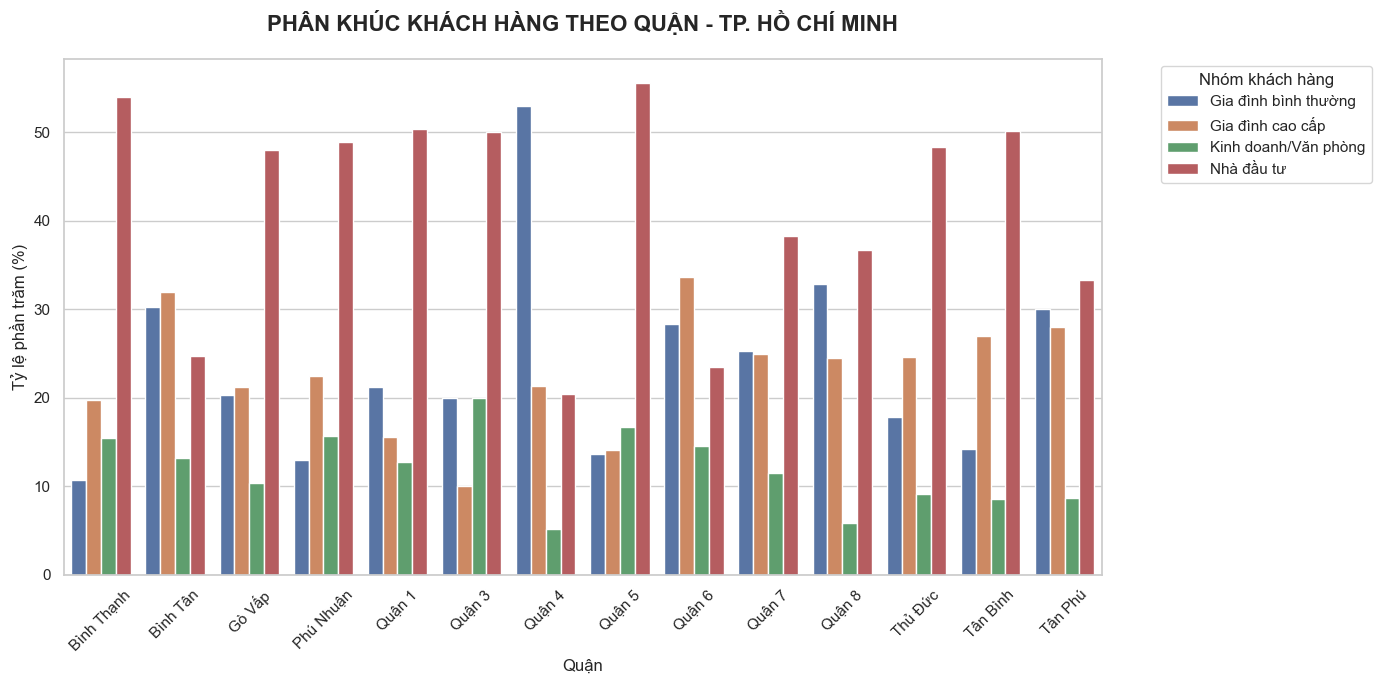

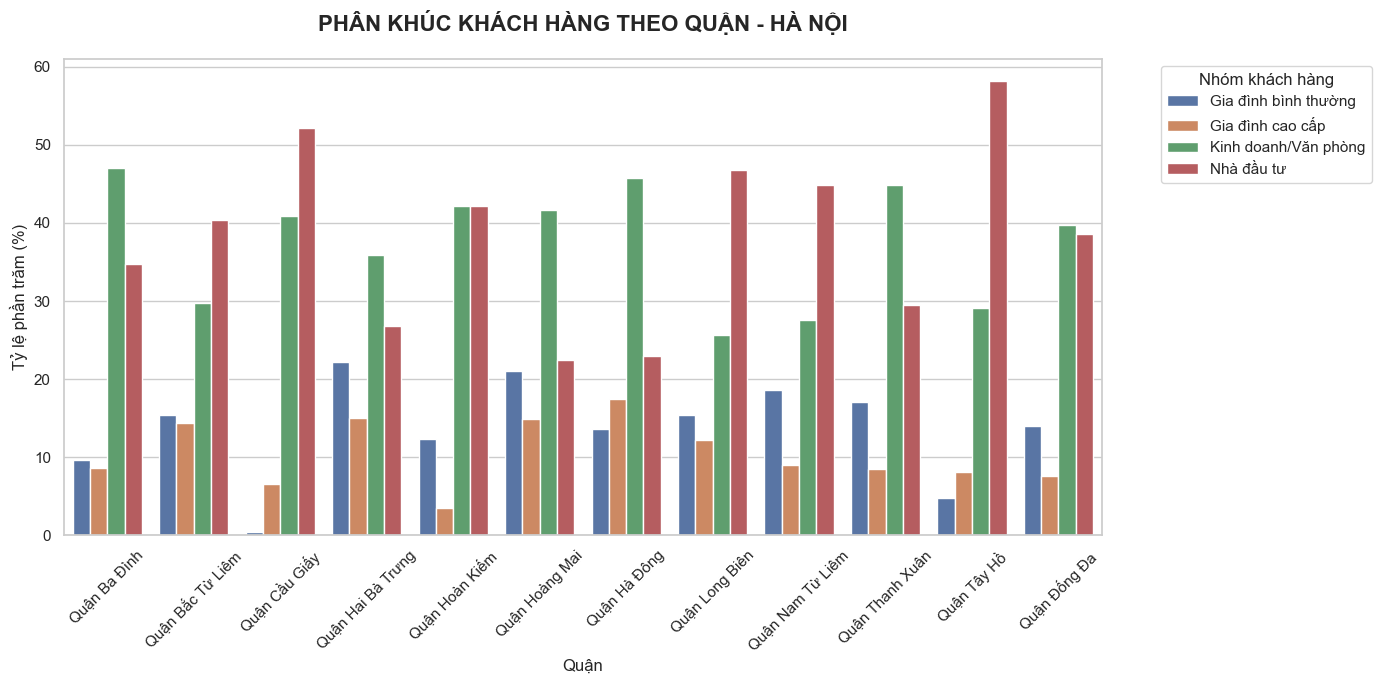

In [ ]:
# Tách dữ liệu cho HCM và Hà Nội
result_hcm = result[result.index.str.contains("TP.HCM")].copy()
result_hn = result[result.index.str.contains("Hà Nội")].copy()

# Làm sạch tên index (bỏ đuôi ", TP.HCM" và ", Hà Nội" để biểu đồ gọn hơn)
result_hcm.index = result_hcm.index.str.replace(", TP.HCM", "")
result_hn.index = result_hn.index.str.replace(", Hà Nội", "")

# Thiết lập style
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial' # Hoặc font hỗ trợ tiếng Việt

def plot_customer_segments(df, title):
    # Vẽ biểu đồ cột nhóm
    df_plot = df.reset_index().melt(id_vars='quan_thanh_pho', var_name='Loại khách hàng', value_name='Tỷ lệ (%)')
    
    plt.figure(figsize=(14, 7))
    ax = sns.barplot(data=df_plot, x='quan_thanh_pho', y='Tỷ lệ (%)', hue='Loại khách hàng')
    
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Quận', fontsize=12)
    plt.ylabel('Tỷ lệ phần trăm (%)', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Nhóm khách hàng', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

if not result_hcm.empty:
    plot_customer_segments(result_hcm, "PHÂN KHÚC KHÁCH HÀNG THEO QUẬN - TP. HỒ CHÍ MINH")

if not result_hn.empty:
    plot_customer_segments(result_hn, "PHÂN KHÚC KHÁCH HÀNG THEO QUẬN - HÀ NỘI")

### Nhận xét

#### Thành phố Hồ Chí Minh

- Biểu đồ cho thấy sự phân hóa rõ rệt về đặc điểm phù hợp của bất động sản giữa các quận. Các loại hình nhà đất phù hợp cho Nhà đầu tư (màu đỏ) chiếm ưu thế tuyệt đối tại các khu vực trung tâm như Bình Thạnh, Phú Nhuận, Quận 1, Quận 3 và cao nhất tại Quận 5 (trên 50%), do sở hữu các đặc điểm về lợi nhuận cho thuê và tính thanh khoản cao.

- Ngược lại, Quận 4 tập trung chủ yếu các bất động sản có thông số phù hợp cho Gia đình bình thường (màu xanh dương) với tỷ lệ áp đảo.

- Các khu vực như Quận 6 và Tân Bình có nguồn cung bất động sản phân bổ đồng đều giữa tiêu chuẩn cho Gia đình cao cấp và Gia đình bình thường.

- Phân khúc phù hợp cho Kinh doanh/Văn phòng (màu xanh lá) chiếm tỷ trọng thấp nhất, cho thấy các bất động sản có cấu trúc chuyên biệt (mặt tiền lớn, có hầm, showroom) là nguồn cung đặc thù và khan hiếm.

#### Hà Nội

- Tại Hà Nội, cấu trúc bất động sản cho thấy sự dẫn dắt mạnh mẽ của các loại hình phù hợp cho Nhà đầu tư và Kinh doanh/Văn phòng.

- Nhóm phù hợp cho Nhà đầu tư (đỏ): Chiếm ưu thế tại các quận có đặc điểm tiềm năng tăng giá và quy hoạch như Tây Hồ (gần 60%), Cầu Giấy và Long Biên; đây là những khu vực có thông số lý tưởng để tích sản.

- Nhóm phù hợp cho Kinh doanh/Văn phòng (xanh lá): Thể hiện sự vượt trội tại các quận lõi và trung tâm hành chính mới như Ba Đình, Thanh Xuân, Hà Đông và Đống Đa, nơi các bất động sản thường có kết cấu hạ tầng ưu tiên cho việc làm trụ sở doanh nghiệp.

- Nhóm phù hợp cho Gia đình (xanh dương & cam): Các bất động sản mang đặc tính thuần để ở chiếm tỷ trọng khá khiêm tốn. Quận Hai Bà Trưng và Hoàng Mai là nơi tập trung nhiều sản phẩm phù hợp cho Gia đình bình thường nhất.

Tổng kết: Dữ liệu cho thấy bất động sản tại Hà Nội có đặc tính phù hợp cao cho việc khai thác thương mại và đầu tư hơn là để ở đơn thuần. Trong khi đó, tại TP.HCM, các loại hình bất động sản có sự phân hóa chức năng rõ rệt theo từng khu vực địa lý, tạo ra nhiều lựa chọn đa dạng cho cả mục đích cư trú lẫn kinh doanh.

## Kết luận

### 1. Đối với Chiến lược Marketing và Quản trị Kinh doanh

Tối ưu hóa ngân sách quảng cáo: Giúp doanh nghiệp phân bổ ngân sách marketing vào đúng các kênh mà phân khúc mục tiêu đang hiện diện (ví dụ: tập trung quảng cáo từ khóa "đầu tư" tại khu vực Quận 5, TP.HCM hoặc Tây Hồ, Hà Nội).

Cá nhân hóa thông điệp truyền thông: Thay vì sử dụng một nội dung chung, marketers có thể điều chỉnh ngôn ngữ quảng cáo phù hợp với đặc tính bất động sản của vùng: nhấn mạnh vào "lợi nhuận" tại Hà Nội và "không gian sống" tại Quận 4, TP.HCM.

Phát triển sản phẩm phù hợp: Giúp các chủ đầu tư xác định loại hình bất động sản nào đang "vắng bóng" hoặc đang là "ưu thế" tại từng quận để ra quyết định xây dựng hoặc cải tạo hợp lý (ví dụ: nhận diện sự khan hiếm của bất động sản kinh doanh tại nhiều khu vực).

### 2. Đối với các Nhóm khách hàng

Nhóm Nhà đầu tư: Nhanh chóng khoanh vùng được các địa điểm có mật độ bất động sản đáp ứng tiêu chí sinh lời cao, giúp tiết kiệm thời gian khảo sát thực địa.

Nhóm Gia đình (Người mua ở thực): Định hướng rõ ràng những khu vực có nguồn cung phù hợp với khả năng tài chính và nhu cầu sinh hoạt (như Quận 4, TP.HCM hoặc Quận Hoàng Mai, Hà Nội).

Nhóm Khách hàng Doanh nghiệp: Xác định được các "điểm nóng" về mặt bằng văn phòng tại Hà Nội để tìm kiếm trụ sở tại những nơi có hạ tầng phù hợp nhất.

### 3. Đối với Môi giới và Đơn vị Phân phối

Tăng tỷ lệ chốt đơn: Môi giới có thể tư vấn dựa trên dữ liệu khách quan về độ phù hợp của tài sản, tạo sự tin tưởng cao hơn cho khách hàng thay vì chỉ dựa vào cảm tính.

Quản lý danh mục sản phẩm: Giúp đại lý lọc được các sản phẩm "ngộp" hoặc "giá tốt" tại những quận có tính thanh khoản cao cho nhà đầu tư để ưu tiên đẩy hàng.

### 2.5 Câu hỏi 5

Cấu trúc kiến trúc của các nhà của từng quận đang ưu tiên cho việc mua đầu tư dài hạn, để ở hay để kinh doanh lấy tiền hàng tháng? Và các khu vực đó có tiềm năng phát triển lớn đến mức nào?"

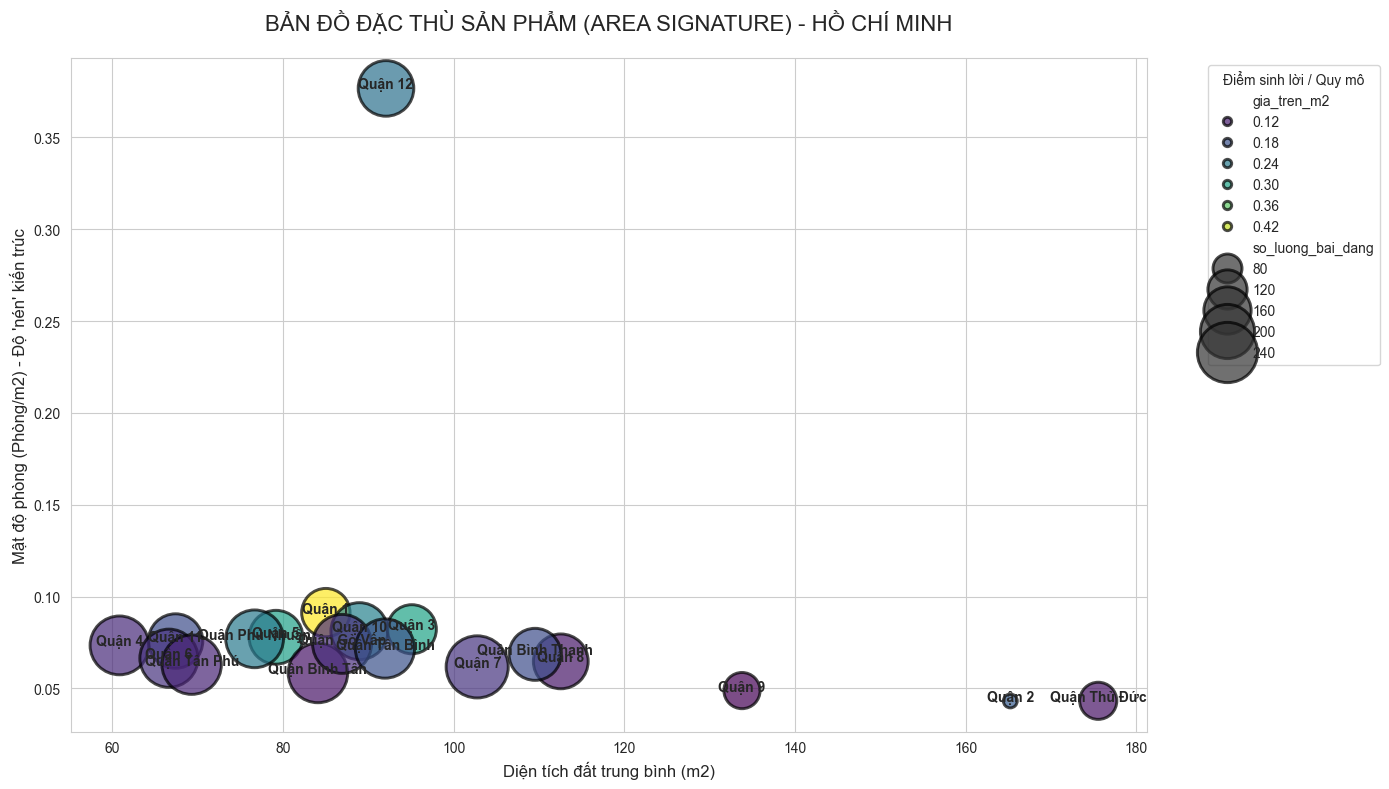

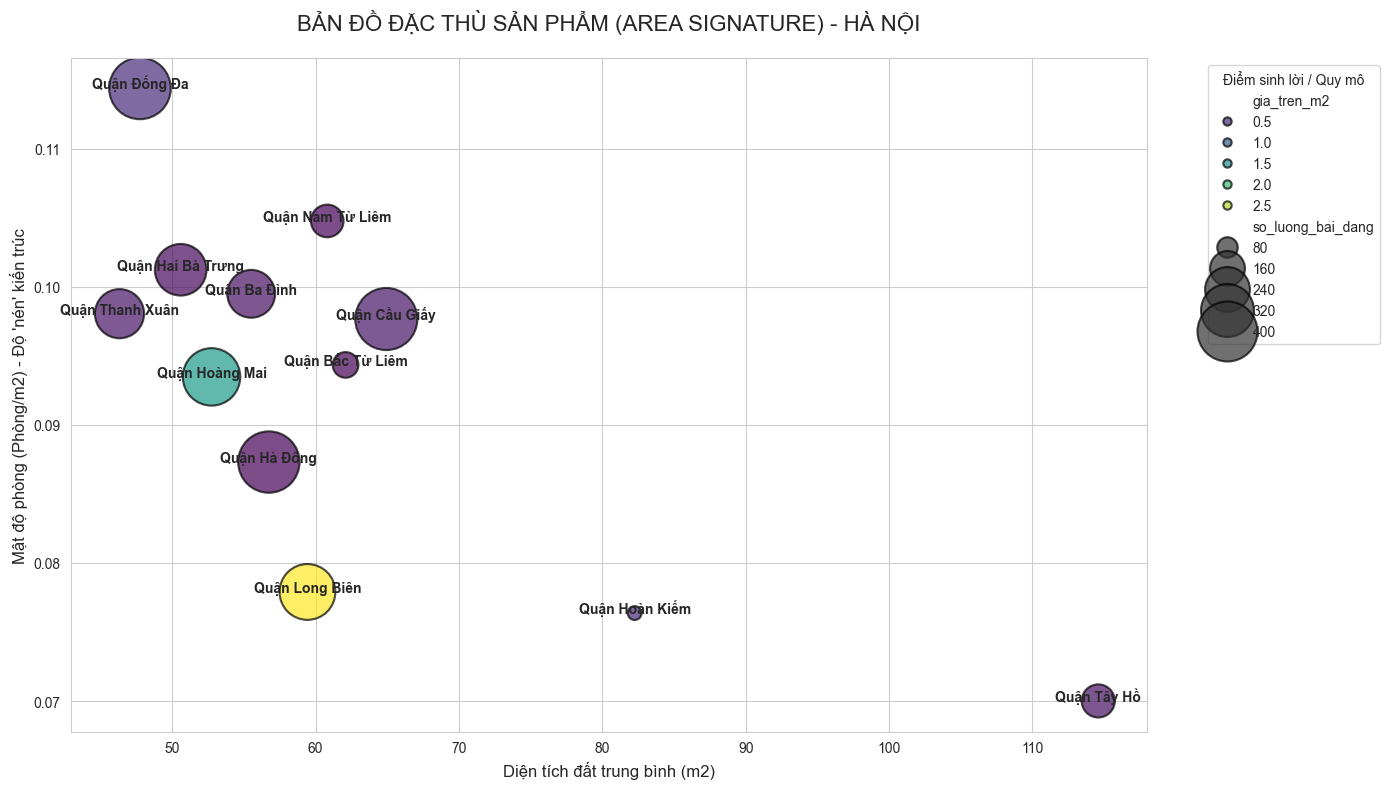

In [29]:
# 1. TÍNH TOÁN CÁC CHỈ SỐ ĐẶC TRƯNG KIẾN TRÚC
# Chỉ số nén không gian: Số phòng ngủ trên mỗi m2 đất
temp_df = df.copy()
temp_df['room_density'] = df['phong_ngu'] / df['dien_tich_dat']

# Hệ số vươn cao: Tương quan giữa số tầng và diện tích (giả định nhà càng cao trên diện tích nhỏ thì hệ số càng lớn)
# Dùng so_tang / diện tích đất để thấy mức độ "tận dụng chiều cao"
temp_df['vertical_ratio'] = df['so_tang'] / df['dien_tich_dat']

# 2. GOM NHÓM THEO QUẬN ĐỂ TÌM "AREA SIGNATURE"
area_signature = temp_df.groupby(['thanh_pho', 'quan']).agg({
    'room_density': 'mean',
    'vertical_ratio': 'mean',
    'dien_tich_dat': 'mean',
    'phong_ngu': 'mean',
    'gia_tren_m2': 'mean',
    'gia': 'count' # Đếm số lượng bài đăng để làm kích thước bong bóng
}).reset_index()

area_signature.rename(columns={'gia': 'so_luong_bai_dang'}, inplace=True)

# 3. TRỰC QUAN HÓA BẰNG BIEU ĐỒ BONG BÓNG 
def plot_area_signature(city_name, data):
    city_data = data[data['thanh_pho'].str.contains(city_name, case=False)]
    
    if city_data.empty:
        return

    plt.figure(figsize=(14, 8))
    sns.set_style("whitegrid")
    
    scatter = sns.scatterplot(
        data=city_data, 
        x='dien_tich_dat', 
        y='room_density', 
        size='so_luong_bai_dang', 
        hue='gia_tren_m2',
        palette='viridis',
        sizes=(100, 2000), 
        alpha=0.7,
        edgecolor='black'
    )

    # Chú thích tên quận cho từng bong bóng
    for i in range(city_data.shape[0]):
        plt.text(
            x=city_data.dien_tich_dat.iloc[i], 
            y=city_data.room_density.iloc[i], 
            s=city_data.quan.iloc[i], 
            fontsize=10, 
            fontweight='bold',
            ha='center'
        )

    plt.title(f"BẢN ĐỒ ĐẶC THÙ SẢN PHẨM (AREA SIGNATURE) - {city_name.upper()}", fontsize=16, pad=20)
    plt.xlabel("Diện tích đất trung bình (m2)", fontsize=12)
    plt.ylabel("Mật độ phòng (Phòng/m2) - Độ 'nén' kiến trúc", fontsize=12)
    plt.legend(title='Điểm sinh lời / Quy mô', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_area_signature("Hồ Chí Minh", area_signature)
plot_area_signature("Hà Nội", area_signature)

## Nhận xét

### Thành phố Hồ Chí Minh

- Biểu đồ cho thấy sự phân hóa rõ rệt về kiến trúc và mục đích sử dụng giữa các khu vực. Quận 12 nằm ở vị trí cao trên trục tung, thể hiện "độ nén" kiến trúc lớn với mật độ phòng cao trên diện tích đất hẹp, phản ánh đặc thù nhiều phòng có thể phù hợp cho thuê trọ hoặc CHDV (căn hộ dịch vụ) khai thác dòng tiền. Ngược lại, Quận 2, Quận 9 và Thủ Đức nằm về phía bên phải trục hoành với diện tích đất trung bình lớn và mật độ phòng thấp, cho thấy đây là vùng đất của các sản phẩm diện tích rộng như biệt thự hoặc nhà phố vườn. Bên cạnh đó quận 1, quận 3 có điểm sinh lời cao nhưng mật độ phòng thấp cho thấy có thể phù hợp để kinh doanh dạng cafe hay nhà hàng.

- Đáng chú ý, các quận có mật độ nén trung bình (Quận 10) thường đi kèm điểm sinh lời cao (màu sáng), chứng minh hiệu quả của việc tối ưu hóa không gian. Trong khi đó, các quận như Bình Tân có quy mô tin đăng lớn (bong bóng to) nhưng mật độ phòng thấp, cho thấy nguồn cung dồi dào ở phân khúc nhà ở thực. Phân tích này giúp nhà đầu tư nhận diện rõ nơi nào ưu tiên cho "dòng tiền" (phía trên) và nơi nào ưu tiên cho "tích sản/không gian sống" (phía bên phải).

### Hà Nội

- Tại Hà Nội, biểu đồ cho thấy một thị trường có sự tập trung cao vào các sản phẩm có tính chất khai thác và kinh doanh. Các quận như Đống Đa, Nam Từ Liêm, Hai Bà Trưng, và Ba Đình nằm ở vùng có mật độ phòng cao ($>0.1$ phòng/$m^2$), phản ánh cấu trúc "nhà ống" nhiều tầng hoặc các tòa nhà văn phòng mini chiếm ưu thế. Đặc biệt, Quận Tây Hồ và Quận Long Biên tách biệt hẳn về phía phải trục hoành với diện tích đất trung bình lớn (từ $60m^2$ đến hơn $110m^2$), cho thấy đây là "thủ phủ" của các bất động sản phù hợp cho Nhà đầu tư.

- Về hiệu quả đầu tư, quận Long Biên ghi nhận điểm sinh lời cao nhất (màu vàng chanh), tương ứng với nhóm bất động sản có tính thanh khoản và tiềm năng tăng giá mạnh.

## Kết luận

Từ những phân tích sâu đặc thù kiến trúc nhà tại hai thị trường lớn nhất cả nước, chúng ta có thể rút ra những kết luận về lợi ích chiến lược như sau:

1. Đối với chiến lược kinh doanh và đầu tư

- Xác định "tọa độ" dòng tiền: Phân tích chỉ ra rõ các quận như Quận 12(TP.HCM) hay Đống Đa, Cầu Giấy (Hà Nội) là nơi có "độ nén" kiến trúc cao, cực kỳ phù hợp cho các mô hình khai thác dòng tiền như CHDV hoặc văn phòng mini.

- Tối ưu hóa danh mục tài sản: Nhà đầu tư có thể dựa vào biểu đồ Area Signature để tìm kiếm các vùng có diện tích đất lớn nhưng mật độ phòng còn thấp (như Quận 9, Quận 2 cũ) để thực hiện chiến lược "mua - cải tạo - tăng mật độ" nhằm đột phá lợi nhuận.

2. Đối với công tác Marketing và bán hàng

- Cá nhân hóa nội dung quảng cáo: Thay vì marketing đại trà, đơn vị phân phối có thể tập trung vào thông điệp "Tiềm năng kinh doanh" tại các quận có tỷ lệ Nhà đầu tư áp đảo, và thông điệp "Không gian sống lý tưởng" tại các quận có diện tích đất trung bình lớn.

- Tư vấn chuyên nghiệp: Việc sử dụng các chỉ số như mật độ phòng (Room Density) giúp môi giới giải thích khoa học về giá trị của bất động sản cho khách hàng, thay vì chỉ tư vấn dựa trên cảm tính.

3. Đối với Quản lý và Phát triển

- Định hướng thiết kế kiến trúc: Chủ đầu tư hoặc người bán có thể điều chỉnh cấu trúc nhà (số phòng, số tầng) sao cho phù hợp với kiến trúc đặc trưng của khu vực đó để dễ dàng thanh khoản nhất.

- Dự báo xu hướng dịch chuyển: Sự khác biệt giữa các quận nội thành cũ và đô thị mới (như Long Biên, Tây Hồ) cho thấy xu hướng dịch chuyển sang các sản phẩm có diện tích lớn hơn nhưng vẫn giữ được khả năng sinh lời cao.